# Individualized Frequency Estimation from Task-Locked EEG
## Feedback- and Decision-Locked Analysis for tACS Frequency Selection

**Goal:** Estimate participant-specific oscillatory peak frequencies (theta, beta, alpha) from EEG recorded during the two-armed bandit task, with cross-run tracking of stimulation aftereffects.

### Methods & Precedents

**Primary approach — task-locked spectral power (Bjekić et al., 2022; van Driel et al., 2015):**
Extract the frequency with peak event-related spectral perturbation (ERSP) from task-locked epochs at frontal electrodes.

**Validation — spectral parameterization (Donoghue et al., 2020):**
Separates aperiodic (1/f) from periodic components to confirm genuine oscillatory peaks.

**Supplementary — PLV (Reinhart & Nguyen, 2019):**
Phase-locking value between frontal and posterior channels. Retained as a connectivity metric, not used for frequency selection (single-site frontal tACS design).

**Exploratory — theta-gamma PAC (Tort et al., 2010):**
Phase-amplitude coupling strength as a potential moderator of tACS response.

### Study design (A-BB-A-A-BB-A)

| Run | Condition | EEG available |
|-----|-----------|---------------|
| 1 | Baseline | ✓ |
| 2 | Active tACS | — |
| 3 | Active tACS | — |
| 4 | Post-active | ✓ |
| 5 | Washout / 2nd baseline | ✓ |
| 6 | Sham tACS | — |
| 7 | Sham tACS | — |
| 8 | Post-sham | ✓ |

**Montage:** 1=F3, 2=Fp1, 3=FCz, 4=FT7, 5=F4, 6=P4, 7=P3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from scipy import signal, stats
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import warnings, time, json
warnings.filterwarnings('ignore', category=RuntimeWarning)

try:
    from specparam import SpectralModel
    SPECPARAM_AVAILABLE = True
    print(f"specparam v{__import__('specparam').__version__}")
except ImportError:
    SPECPARAM_AVAILABLE = False
    print("specparam not installed — pip install specparam")

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.labelsize': 12,
                     'axes.titlesize': 13, 'font.size': 11, 'lines.linewidth': 1.5})


specparam v2.0.0rc6


## Step 0: Configuration

In [4]:
# ══════════════════════════════════════════════════════════════
# CONFIGURATION — edit SUBJECT_IDS and DATA_ROOT only
# ══════════════════════════════════════════════════════════════
import glob

DATA_ROOT = Path("~/Documents/GitHub/tacs_bandit/data").expanduser()
NIC_DIR = DATA_ROOT / "nic" / "raw"
BEHAV_ROOT = DATA_ROOT / "bandit"

# ── List the subjects you want to process ──
SUBJECT_IDS = ['rebecca-pilot-2', '11440', '10685', '11116']

# ── Active/sham run mapping per subject (or use a default) ──
# Keys: subject ID. Values: dict with 'active_runs' and 'sham_runs'
# Runs with EEG are always 1, 4, 5, 8 in the A-BB-A-A-BB-A design
STIM_DESIGN = {
    'default': {
        1: 'Baseline',
        4: 'Post-active',
        5: 'Washout',
        8: 'Post-sham',
    },
    # Override per subject if counterbalancing differs:
    # 'some-subject': {1: 'Baseline', 4: 'Post-sham', 5: 'Washout', 8: 'Post-active'},
}

EEG_RUNS = [1, 4, 5, 8]

# ── Auto-discover file paths ──
def discover_files(sub_id):
    """Find .easy and .csv files for a subject, matching by sub-ID and run number."""
    runs = {}
    conditions = STIM_DESIGN.get(sub_id, STIM_DESIGN['default'])
    
    for run_num in EEG_RUNS:
        # Find .easy file: pattern like *_sub-{sub_id}_Run {run_num}.easy
        easy_pattern = str(NIC_DIR / f"*_sub-{sub_id}_Run {run_num}.easy")
        easy_matches = glob.glob(easy_pattern)
        
        # Find .csv file: pattern like sub-{sub_id}/sub-{sub_id}_ses-1_run-{run_num:02d}_*.csv
        csv_dir = BEHAV_ROOT / f"sub-{sub_id}"
        csv_pattern = str(csv_dir / f"sub-{sub_id}_ses-1_run-{run_num:02d}_*.csv")
        csv_matches = glob.glob(csv_pattern)
        
        if not easy_matches:
            print(f"  ⚠ Run {run_num}: no .easy file found ({easy_pattern})")
            continue
        if not csv_matches:
            print(f"  ⚠ Run {run_num}: no .csv file found ({csv_pattern})")
            continue
        
        runs[run_num] = {
            'easy': Path(easy_matches[0]),
            'csv': Path(csv_matches[0]),
            'condition': conditions[run_num],
        }
    
    return runs

# Discover all subjects
ALL_SUBJECTS = {}
for sub_id in SUBJECT_IDS:
    print(f"\nDiscovering files for sub-{sub_id}:")
    runs = discover_files(sub_id)
    if runs:
        ALL_SUBJECTS[sub_id] = runs
        for rn, info in sorted(runs.items()):
            print(f"  Run {rn} ({info['condition']}): ✓")
            print(f"    EEG: {info['easy'].name}")
            print(f"    CSV: {info['csv'].name}")
    else:
        print(f"  ✗ No data found!")

print(f"\n{'='*60}")
print(f"Subjects ready: {list(ALL_SUBJECTS.keys())}")

# ── Which subject to analyze in this run of the notebook? ──
###############################################################
# Change this to switch between subjects: #####################
CURRENT_SUBJECT = SUBJECT_IDS[3]
RUNS = ALL_SUBJECTS[CURRENT_SUBJECT]
print(f"\n▶ Active subject: {CURRENT_SUBJECT}")
###############################################################

# ══════════════════════════════════════════════════════════════
# EEG parameters (these don't change between subjects)
# ══════════════════════════════════════════════════════════════
CHANNEL_MAP = {0:'F3', 1:'Fp1', 2:'FCz', 3:'FT7', 4:'F4', 5:'P4', 6:'P3'}
N_EEG_CH = 7
SRATE = 500
NV_TO_UV = 1e-3

FRONTAL_ROI = ['FCz', 'F3', 'F4']
POSTERIOR_ROI = ['FT7', 'P3', 'P4']
POSTERIOR_ALPHA_ROI = ['P3', 'P4']

HIGHPASS = 0.5
LOWPASS = 45.0
NOTCH = 60.0
FP1_BLINK_THRESH_UV = None  # Disabled

TRIAL_TIMING = {
    'fixation_duration': 0.5,
    'max_response_time': 2.0,
    'choice_highlight_duration': 0.5,
    'wait_duration': 2.0,
    'outcome_duration': 1.0,
    'iti_duration': 0.25,
}

EPOCH_TMIN = -1.5
EPOCH_TMAX = 2.0
BASELINE_WIN = (-0.8, -0.1)
FEEDBACK_WIN = (0.1, 1.5)
DECISION_PRE_RESP = (-1.0, -0.1)

BANDS = {'theta': (4.0, 8.0), 'alpha': (8.0, 13.0), 'beta': (13.0, 30.0)}
THETA_STEP = 0.25

EPOCH_REJECT_UV = 200.0
STIM_FREQ_HZ = 6.0



Discovering files for sub-rebecca-pilot-2:
  Run 1 (Baseline): ✓
    EEG: 20260602150340_sub-rebecca-pilot-2_Run 1.easy
    CSV: sub-rebecca-pilot-2_ses-1_run-01_task-bandit_2026-06-02_15-02-09.csv
  Run 4 (Post-active): ✓
    EEG: 20260602152550_sub-rebecca-pilot-2_Run 4.easy
    CSV: sub-rebecca-pilot-2_ses-1_run-04_task-bandit_2026-06-02_15-02-09.csv
  Run 5 (Washout): ✓
    EEG: 20260602153834_sub-rebecca-pilot-2_Run 5.easy
    CSV: sub-rebecca-pilot-2_ses-1_run-05_task-bandit_2026-06-02_15-02-09.csv
  Run 8 (Post-sham): ✓
    EEG: 20260602155905_sub-rebecca-pilot-2_Run 8.easy
    CSV: sub-rebecca-pilot-2_ses-1_run-08_task-bandit_2026-06-02_15-02-09.csv

Discovering files for sub-11440:
  Run 1 (Baseline): ✓
    EEG: 20260608140424_sub-11440_Run 1.easy
    CSV: sub-11440_ses-1_run-01_task-bandit_2026-06-08_14-02-30.csv
  Run 4 (Post-active): ✓
    EEG: 20260608142730_sub-11440_Run 4.easy
    CSV: sub-11440_ses-1_run-04_task-bandit_2026-06-08_14-02-30.csv
  Run 5 (Washout): ✓
    E

## Step 1: Shared Functions

In [6]:
def preprocess(eeg, srate, hp=0.5, lp=45.0, notch=60.0, bad_ch=None):
    """Bandpass, notch, average re-reference.
    
    Note on double notch filtering: If NIC-2 already applied a 60 Hz notch during
    recording, applying a second one here simply deepens the notch. Both are narrow
    (Q=30, ~±2 Hz) so there is no distortion of neighboring frequencies.
    """
    out = eeg.copy()
    nyq = srate / 2.0
    b, a = signal.butter(4, [hp/nyq, lp/nyq], btype='band')
    out = signal.filtfilt(b, a, out, axis=0)
    if 0 < notch < nyq:
        bn, an = signal.iirnotch(notch/nyq, Q=30.0)
        out = signal.filtfilt(bn, an, out, axis=0)
    bad_ch = bad_ch or []
    good = [i for i in range(out.shape[1]) if i not in bad_ch]
    out -= np.mean(out[:, good], axis=1, keepdims=True)
    return out

def epoch_at_offset(eeg, srate, event_times, offset, tmin, tmax,
                    reject_uv=200, fp1_thresh=None, fp1_idx=None):
    """Extract epochs with timing offset, artifact rejection, and optional
    Fp1-specific blink rejection."""
    n_pre = int(round(abs(tmin) * srate))
    n_post = int(round(tmax * srate))
    n_epoch = n_pre + n_post
    times = np.arange(n_epoch) / srate + tmin
    epochs, kept = [], []
    n_blink_reject = 0
    for i, t in enumerate(event_times):
        if np.isnan(t): continue
        center = int(round((t + offset) * srate))
        s0, s1 = center - n_pre, center + n_post
        if s0 < 0 or s1 > len(eeg): continue
        ep = eeg[s0:s1]
        if ep.shape[0] != n_epoch: continue
        # Global threshold
        if np.max(np.abs(ep)) > reject_uv: continue
        # Fp1-specific blink threshold
        if fp1_thresh and fp1_idx is not None:
            if np.max(np.abs(ep[:, fp1_idx])) > fp1_thresh:
                n_blink_reject += 1
                continue
        # Linear detrend per channel
        for ci in range(ep.shape[1]):
            ep[:, ci] = signal.detrend(ep[:, ci], type='linear')
        epochs.append(ep)
        kept.append(i)
    if not epochs:
        return np.empty((0, n_epoch, eeg.shape[1])), times, kept, n_blink_reject
    return np.stack(epochs), times, kept, n_blink_reject

def find_best_offset(eeg, srate, event_times, ch_idx, offsets=None,
                     fp1_thresh=None, fp1_idx=None):
    """Sweep offsets and find the one maximizing FRN->P300 at a given channel."""
    event_times = event_times[~np.isnan(event_times)]
    if offsets is None:
        offsets = np.arange(-2.0, 5.01, 0.1)
    scores = []
    counts = []
    for off in offsets:
        ep, t, kept, _ = epoch_at_offset(eeg, srate, event_times, off,
                                          -0.5, 1.0, reject_uv=300,
                                          fp1_thresh=fp1_thresh, fp1_idx=fp1_idx)
        counts.append(len(kept))
        if len(kept) < 10:
            scores.append(0); continue
        erp = np.mean(ep[:, :, ch_idx], axis=0)
        bl = (t >= -0.3) & (t <= -0.05)
        erp -= np.mean(erp[bl])
        frn = np.min(erp[(t >= 0.2) & (t <= 0.35)])
        p3 = np.max(erp[(t >= 0.3) & (t <= 0.5)])
        scores.append(p3 - frn)
    scores = np.array(scores)
    best_idx = np.argmax(scores)
    return offsets[best_idx], scores, counts

def morlet_tfr(epochs, srate, freqs, n_cycles=5, ch_idx=None):
    n_ep, n_times, n_ch = epochs.shape
    ch_idx = ch_idx or list(range(n_ch))
    power = np.zeros((len(freqs), n_times))
    for fi, f in enumerate(freqs):
        sigma_t = n_cycles / (2*np.pi*f)
        hw = int(np.ceil(3.5*sigma_t*srate))
        t_wav = np.arange(-hw, hw+1) / srate
        wav = np.exp(2j*np.pi*f*t_wav) * np.exp(-t_wav**2/(2*sigma_t**2))
        wav /= np.sqrt(np.sum(np.abs(wav)**2))
        for ci in ch_idx:
            for ei in range(n_ep):
                power[fi] += np.abs(signal.fftconvolve(epochs[ei,:,ci], wav, mode='same'))**2
        power[fi] /= (n_ep * len(ch_idx))
    return power

def find_band_peak(freqs, spectrum, band, smooth_sigma=1.0):
    mask = (freqs >= band[0]) & (freqs <= band[1])
    bf, bs = freqs[mask], spectrum[mask]
    if len(bf) == 0: return None, None, None
    bs_s = gaussian_filter1d(bs, sigma=smooth_sigma) if smooth_sigma > 0 else bs
    pk = np.argmax(bs_s)
    return float(bf[pk]), float(bs_s[pk]), pk in {0, len(bf)-1}

def specparam_band_peak(freqs, psd, band, freq_range=(2, 40)):
    if not SPECPARAM_AVAILABLE: return None, None
    sm = SpectralModel(peak_width_limits=[1.0, 8.0], max_n_peaks=6,
                       min_peak_height=0.05, aperiodic_mode='fixed')
    sm.fit(freqs, psd, freq_range=list(freq_range))
    pk = sm.results.params.periodic.params
    best_cf, best_pw = None, 0
    if pk.size > 0 and pk.ndim == 2:
        for p in pk:
            if band[0] <= p[0] <= band[1] and p[1] > best_pw:
                best_cf, best_pw = p[0], p[1]
    return (float(best_cf) if best_cf else None, sm)

def cluster_permutation_test(data_a, data_b, times, n_perm=1000, alpha=0.05):
    """Cluster-based permutation test (Maris & Oostenveld, 2007).
    
    Tests whether the mean of data_a differs from data_b at any time points,
    controlling for multiple comparisons by clustering adjacent significant
    time points and comparing cluster mass to a null distribution.
    
    Parameters
    ----------
    data_a, data_b : (n_trials, n_times)
    times : (n_times,) in seconds
    
    Returns
    -------
    clusters : list of (time_mask, p_value, t_sum) for significant clusters
    t_obs : observed t-statistic at each time point
    """
    n_a, n_t = data_a.shape
    n_b = data_b.shape[0]
    all_data = np.vstack([data_a, data_b])
    labels = np.array([0]*n_a + [1]*n_b)
    
    def get_clusters(t_vals, thresh):
        above = np.abs(t_vals) > thresh
        clusters = []
        in_cluster = False
        start = 0
        for i in range(len(above)):
            if above[i] and not in_cluster:
                start = i; in_cluster = True
            elif not above[i] and in_cluster:
                clusters.append((start, i, np.sum(t_vals[start:i])))
                in_cluster = False
        if in_cluster:
            clusters.append((start, len(above), np.sum(t_vals[start:])))
        return clusters
    
    # Observed t-stats
    t_obs, _ = stats.ttest_ind(data_a, data_b, axis=0)
    t_thresh = stats.t.ppf(1 - alpha/2, n_a + n_b - 2)
    obs_clusters = get_clusters(t_obs, t_thresh)
    
    if not obs_clusters:
        return [], t_obs
    
    # Null distribution of max cluster mass
    max_cluster_masses = np.zeros(n_perm)
    for pi in range(n_perm):
        perm_labels = np.random.permutation(labels)
        pa = all_data[perm_labels == 0]
        pb = all_data[perm_labels == 1]
        t_perm, _ = stats.ttest_ind(pa, pb, axis=0)
        perm_clusters = get_clusters(t_perm, t_thresh)
        if perm_clusters:
            max_cluster_masses[pi] = max(abs(c[2]) for c in perm_clusters)
    
    # p-values
    results = []
    for start, end, t_sum in obs_clusters:
        p = np.mean(max_cluster_masses >= abs(t_sum))
        mask = np.zeros(n_t, dtype=bool)
        mask[start:end] = True
        results.append((mask, p, t_sum))
    
    return results, t_obs

def compute_plv_spectrum(epochs, srate, ch_a, ch_b, times, win, freqs, bw=1.0):
    win_mask = (times >= win[0]) & (times <= win[1])
    n_ep = len(epochs); nyq = srate / 2.0
    plv_spec = np.zeros(len(freqs))
    for fi, fc in enumerate(freqs):
        lo, hi = max(fc-bw/2, 0.5), min(fc+bw/2, nyq-1)
        if lo >= hi: continue
        b, a = signal.butter(3, [lo/nyq, hi/nyq], btype='band')
        pair_plvs = []
        for ci_a in ch_a:
            for ci_b in ch_b:
                pa = np.zeros((n_ep, win_mask.sum()))
                pb = np.zeros((n_ep, win_mask.sum()))
                for ei in range(n_ep):
                    pa[ei] = np.angle(signal.hilbert(signal.filtfilt(b, a, epochs[ei,:,ci_a]))[win_mask])
                    pb[ei] = np.angle(signal.hilbert(signal.filtfilt(b, a, epochs[ei,:,ci_b]))[win_mask])
                plv = np.abs(np.mean(np.exp(1j*(pa-pb)), axis=0))
                pair_plvs.append(np.mean(plv))
        plv_spec[fi] = np.mean(pair_plvs)
    return plv_spec

def compute_pac_mi(epochs, srate, ch_idx, times, win,
                   phase_band=(4,8), amp_band=(25,45), n_bins=18):
    win_mask = (times >= win[0]) & (times <= win[1])
    nyq = srate / 2.0
    bp, ap = signal.butter(3, [phase_band[0]/nyq, phase_band[1]/nyq], btype='band')
    ba, aa = signal.butter(3, [amp_band[0]/nyq, amp_band[1]/nyq], btype='band')
    all_ph, all_am = [], []
    for ei in range(len(epochs)):
        for ci in ch_idx:
            sig = epochs[ei,:,ci]
            ph = np.angle(signal.hilbert(signal.filtfilt(bp, ap, sig)))[win_mask]
            am = np.abs(signal.hilbert(signal.filtfilt(ba, aa, sig)))[win_mask]
            all_ph.append(ph); all_am.append(am)
    all_ph, all_am = np.concatenate(all_ph), np.concatenate(all_am)
    bins = np.linspace(-np.pi, np.pi, n_bins+1)
    mean_amp = np.array([np.mean(all_am[(all_ph >= bins[i]) & (all_ph < bins[i+1])])
                         if ((all_ph >= bins[i]) & (all_ph < bins[i+1])).sum() > 0 else 0
                         for i in range(n_bins)])
    mn = mean_amp / (mean_amp.sum() + 1e-30) + 1e-12
    mn /= mn.sum()
    mi = np.sum(mn * np.log(mn * n_bins)) / np.log(n_bins)
    return mi, mean_amp, bins

ch_names = [CHANNEL_MAP[i] for i in range(N_EEG_CH)]
fcz_idx = ch_names.index('FCz')
fp1_idx = ch_names.index('Fp1')
frontal_ch_idx = [ch_names.index(c) for c in FRONTAL_ROI]
posterior_ch_idx = [ch_names.index(c) for c in POSTERIOR_ROI]
posterior_alpha_idx = [ch_names.index(c) for c in POSTERIOR_ALPHA_ROI]

print("Functions and indices defined.")
print(f"Channels: {ch_names}")
print(f"Frontal ROI: {FRONTAL_ROI} → {frontal_ch_idx}")
print(f"Posterior ROI: {POSTERIOR_ROI} → {posterior_ch_idx}")


Functions and indices defined.
Channels: ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3']
Frontal ROI: ['FCz', 'F3', 'F4'] → [2, 0, 4]
Posterior ROI: ['FT7', 'P3', 'P4'] → [3, 6, 5]


## Step 2: Load & Preprocess All Runs

In [8]:
BAD_CH_IDX = []
run_data = {}

for run_num, info in RUNS.items():
    print(f"\n{'='*60}")
    print(f"Run {run_num}: {info['condition']}")
    print(f"{'='*60}")
    
    # Load EEG
    raw = np.loadtxt(info['easy'])
    eeg = raw[:, :N_EEG_CH] * NV_TO_UV
    dur = len(eeg) / SRATE
    print(f"  EEG: {raw.shape} → {dur:.1f}s ({dur/60:.1f} min)")
    
    # Preprocess
    eeg_c = preprocess(eeg, SRATE, HIGHPASS, LOWPASS, NOTCH, BAD_CH_IDX)
    
    # Load behavior
    bdf = pd.read_csv(info['csv'])
    bdf['rt_sec'] = bdf['rt'] / 1000.0
    bdf['feedback_onset'] = bdf['trial_start_time'] + bdf['rt_sec'] + 2.0
    bdf['response_time'] = bdf['trial_start_time'] + bdf['rt_sec']
    n_miss = bdf['rt'].isna().sum()
    if n_miss > 0:
        print(f"  Note: {n_miss} missed trials (NaN RT) — will be skipped")
    print(f"  Trials: {len(bdf)}, Reward: {bdf['reward'].sum()}/{len(bdf)}")
    
    # Find alignment offset
    offset, scores, counts = find_best_offset(
        eeg_c, SRATE, bdf['feedback_onset'].values, fcz_idx,
        fp1_thresh=FP1_BLINK_THRESH_UV, fp1_idx=fp1_idx
    )
    best_score = scores[np.argmax(scores)]
    print(f"  Alignment offset: {offset:.1f}s (FRN score: {best_score:.2f} µV)")
    if best_score < 1.0:
        print(f"  ⚠ LOW alignment confidence — FRN→P300 score < 1.0 µV. ERP may be weak for this participant.")
    if abs(offset) > 4.0:
        print(f"  ⚠ LARGE offset ({offset:.1f}s) — check NIC start timing for this run.")
    
    # Extract feedback epochs
    ep_fb, t_fb, kept_fb, n_blink = epoch_at_offset(
        eeg_c, SRATE, bdf['feedback_onset'].values, offset,
        EPOCH_TMIN, EPOCH_TMAX, EPOCH_REJECT_UV,
        fp1_thresh=FP1_BLINK_THRESH_UV, fp1_idx=fp1_idx
    )
    rew = bdf['reward'].values[kept_fb].astype(bool)
    print(f"  Feedback epochs: {len(kept_fb)} (rejected: {len(bdf)-len(kept_fb)}, blink: {n_blink})")
    print(f"    Win: {rew.sum()}, Loss: {np.logical_not(rew).sum()}")
    
    # Extract decision epochs
    ep_dec, t_dec, kept_dec, _ = epoch_at_offset(
        eeg_c, SRATE, bdf['response_time'].values, offset,
        -1.5, 0.5, EPOCH_REJECT_UV,
        fp1_thresh=FP1_BLINK_THRESH_UV, fp1_idx=fp1_idx
    )
    print(f"  Decision epochs: {len(kept_dec)}")
    
    run_data[run_num] = {
        'eeg_clean': eeg_c, 'bdf': bdf, 'offset': offset,
        'ep_fb': ep_fb, 't_fb': t_fb, 'kept_fb': kept_fb, 'reward': rew,
        'ep_dec': ep_dec, 't_dec': t_dec, 'kept_dec': kept_dec,
        'condition': info['condition'],
    }

print(f"\n\nAll runs loaded. Available: {list(run_data.keys())}")



Run 1: Baseline
  EEG: (180000, 13) → 360.0s (6.0 min)
  Trials: 71, Reward: 30/71
  Alignment offset: 4.0s (FRN score: 2.15 µV)
  ⚠ LARGE offset (4.0s) — check NIC start timing for this run.
  Feedback epochs: 69 (rejected: 2, blink: 0)
    Win: 29, Loss: 40
  Decision epochs: 69

Run 4: Post-active
  EEG: (180000, 13) → 360.0s (6.0 min)
  Note: 2 missed trials (NaN RT) — will be skipped
  Trials: 69, Reward: 34/69
  Alignment offset: 2.2s (FRN score: 2.14 µV)
  Feedback epochs: 63 (rejected: 6, blink: 0)
    Win: 33, Loss: 30
  Decision epochs: 65

Run 5: Washout
  EEG: (180000, 13) → 360.0s (6.0 min)
  Trials: 70, Reward: 42/70
  Alignment offset: -1.1s (FRN score: 1.89 µV)
  Feedback epochs: 69 (rejected: 1, blink: 0)
    Win: 41, Loss: 28
  Decision epochs: 68

Run 8: Post-sham
  EEG: (180000, 13) → 360.0s (6.0 min)
  Trials: 70, Reward: 38/70
  Alignment offset: 4.2s (FRN score: 2.05 µV)
  ⚠ LARGE offset (4.2s) — check NIC start timing for this run.
  Feedback epochs: 68 (reject

In [9]:
# ── Preprocessing note ──
# Fp1 blink threshold: DISABLED (was causing 49-78% epoch loss at 100-150 µV).
# Average reference: ALL 7 channels (including Fp1). Excluding Fp1 from the 
# reference destabilized the alignment sweep. The minor blink leakage (~15 µV  
# at FCz per blink) is handled by epoch averaging across 70+ trials.
# Fp1 is not in any analysis ROI, so blink contamination at Fp1 itself is irrelevant.
print(f"Global artifact threshold: ±{EPOCH_REJECT_UV} µV")
print(f"Fp1-specific threshold: {FP1_BLINK_THRESH_UV} (disabled)")
print("Average reference: all 7 channels (Fp1 included in ref, excluded from ROIs)")


Global artifact threshold: ±200.0 µV
Fp1-specific threshold: None (disabled)
Average reference: all 7 channels (Fp1 included in ref, excluded from ROIs)


## Step 3: Trial Structure & Full-Trial EEG Visualization

Each trial follows this sequence (from `bandit_main.py`):

1. **Fixation cross** (500 ms)
2. **Stimulus presentation** — participant views the two bandits
3. **Response** — button press (up to 2000 ms)
4. **Choice highlight** (500 ms)
5. **Blank screen / wait** (2000 ms)
6. **Feedback / outcome** (1000 ms)
7. **ITI** (250 ms)

Below we construct a full-trial TFR showing where beta and theta effects should appear.


Full-trial epochs: 69 (Run 1)
Computing full-trial TFR... done (0.4s)


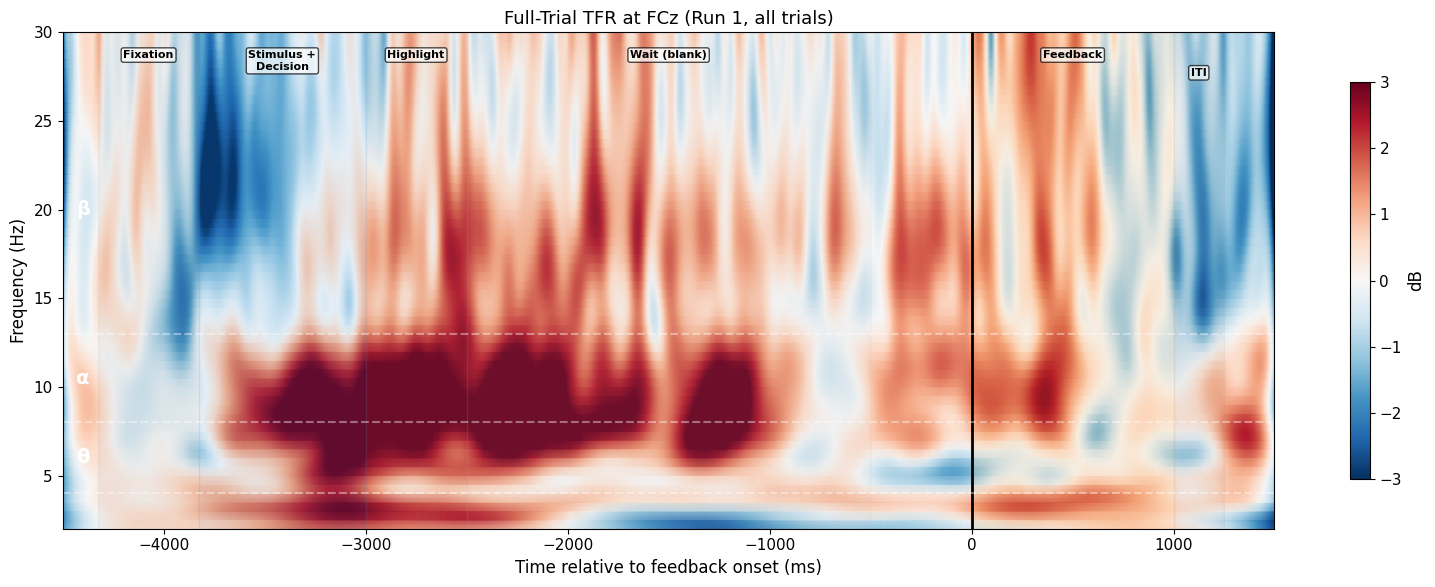

In [11]:
# ── Build full-trial epochs for Run 1 ──
# Anchor to stimulus onset: trial_start_time + fixation(0.5s) - offset...
# Actually, it's cleaner to anchor to feedback onset and extend backward far enough
# to capture the full trial. From feedback onset, going back:
#   feedback - wait(2.0) - highlight(0.5) - RT - fixation(0.5) ≈ fb - 3.5 to 4.0s
# So an epoch from -4.5 to +1.5 relative to feedback captures the whole trial.

rd = run_data[1]
full_ep, full_t, full_kept, _ = epoch_at_offset(
    rd['eeg_clean'], SRATE, rd['bdf']['feedback_onset'].values, rd['offset'],
    -4.5, 1.5, reject_uv=250,
    fp1_thresh=FP1_BLINK_THRESH_UV, fp1_idx=fp1_idx
)
full_rew = rd['bdf']['reward'].values[full_kept]
mean_rt = rd['bdf']['rt_sec'].mean()

print(f"Full-trial epochs: {len(full_kept)} (Run 1)")

# TFR across 2-30 Hz
full_freqs = np.arange(2.0, 30.25, 0.5)
print("Computing full-trial TFR...", end=' ')
t0 = time.time()
tfr_full = morlet_tfr(full_ep, SRATE, full_freqs, n_cycles=5, ch_idx=[fcz_idx])
print(f"done ({time.time()-t0:.1f}s)")

# Baseline: early part of the epoch (-4.5 to -4.0s, i.e., before fixation)
bl_full = (full_t >= -4.5) & (full_t <= -4.0)
bl_pw = np.mean(tfr_full[:, bl_full], axis=1, keepdims=True)
bl_pw = np.maximum(bl_pw, 1e-30)
tfr_full_db = 10 * np.log10(np.maximum(tfr_full, 1e-30) / bl_pw)

# ── Plot ──
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.pcolormesh(full_t*1000, full_freqs, tfr_full_db, shading='gouraud',
                    cmap='RdBu_r', vmin=-3, vmax=3)
ax.set_xlabel('Time relative to feedback onset (ms)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Full-Trial TFR at FCz (Run 1, all trials)')
fig.colorbar(im, ax=ax, label='dB', shrink=0.8)

# Mark trial phases (approximate, relative to feedback onset at t=0)
phases = [
    (-3.0 - mean_rt - 0.5, -3.0 - mean_rt, 'Fixation', 'gray'),
    (-3.0 - mean_rt, -3.0, 'Stimulus +\nDecision', '#2196F3'),
    (-3.0, -2.5, 'Highlight', '#9E9E9E'),
    (-2.5, -0.5, 'Wait (blank)', '#BDBDBD'),
    (0.0, 1.0, 'Feedback', '#FF9800'),
    (1.0, 1.25, 'ITI', 'gray'),
]
for t_start, t_end, label, color in phases:
    ax.axvspan(t_start*1000, t_end*1000, alpha=0.08, color=color)
    y_pos = 29 if label != 'ITI' else 28
    ax.text((t_start+t_end)/2*1000, y_pos, label, ha='center', va='top',
            fontsize=8, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.axvline(0, color='black', lw=2)
ax.axhline(4, color='white', ls='--', alpha=0.4)
ax.axhline(8, color='white', ls='--', alpha=0.4)
ax.axhline(13, color='white', ls='--', alpha=0.4)
ax.axhline(30, color='white', ls='--', alpha=0.4)

# Band labels
for freq, label in [(6, 'θ'), (10.5, 'α'), (20, 'β')]:
    ax.text(-4400, freq, label, fontsize=14, fontweight='bold', color='white',
            ha='center', va='center')

fig.tight_layout()
plt.show()


## Step 4: Feedback-Locked ERPs with Permutation Statistics

The y-axis of ERP plots shows voltage in **microvolts (µV)** — the electrical potential at the scalp, averaged across trials. This is not theta or any specific oscillatory frequency; it's the raw time-domain signal that survives averaging. Anything not consistently time-locked to feedback onset cancels out across trials, leaving the event-related potential (ERP).

Key components:
- **FRN (200–350 ms):** Feedback-related negativity, larger (more negative) for losses. Reflects negative prediction error signaling from medial prefrontal cortex.
- **Reward positivity / P300 (400–800 ms):** Positive deflection, larger for wins. Reflects positive prediction error and reward evaluation. This is why the win/loss traces "flip" around 500 ms — it's not noise, it's the second component of the prediction error response.

Cluster-based permutation tests (Maris & Oostenveld, 2007) identify time windows where the win/loss difference is statistically significant while controlling for multiple comparisons.


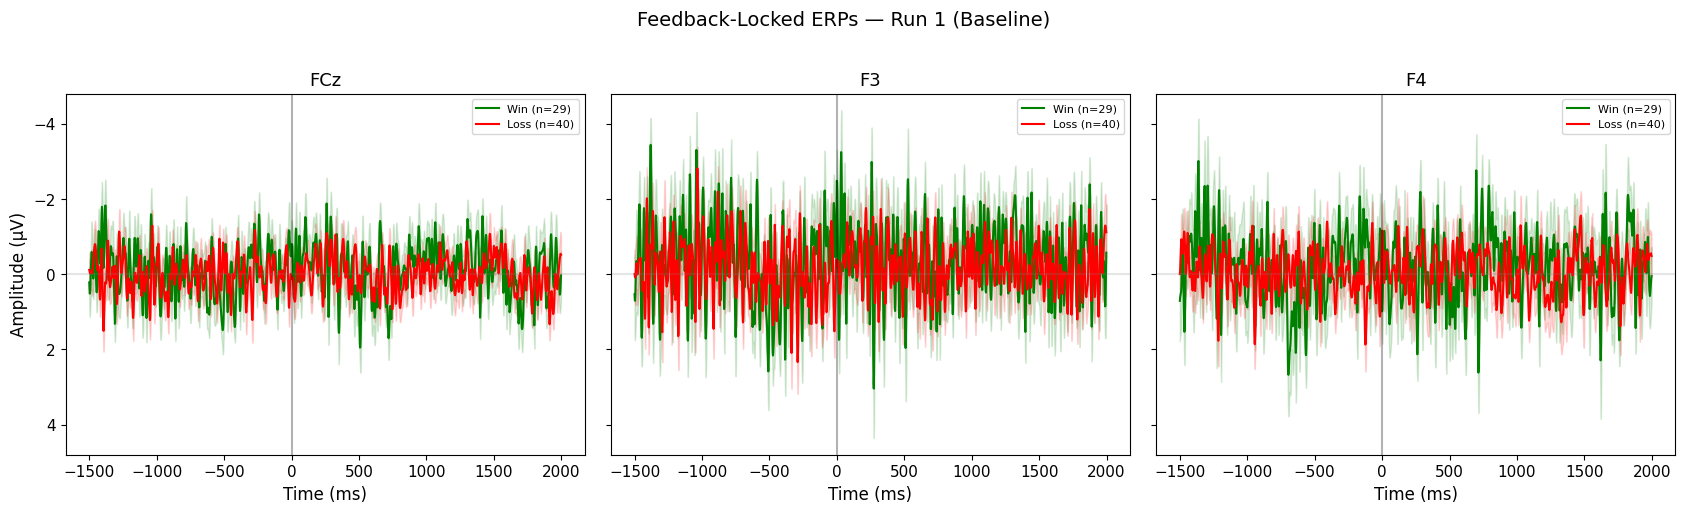

Cluster-based permutation test at FCz (win vs loss):
  Cluster 1: -1402–-1396 ms, t_sum=-8.9, p=1.000 
  Cluster 2: -1386–-1376 ms, t_sum=-15.3, p=0.951 
  Cluster 3: -1312–-1308 ms, t_sum=6.8, p=1.000 
  Cluster 4: -1048–-1042 ms, t_sum=-9.8, p=0.999 
  Cluster 5: -612–-610 ms, t_sum=4.0, p=1.000 
  Cluster 6: -536–-530 ms, t_sum=9.0, p=1.000 
  Cluster 7: -514–-504 ms, t_sum=17.3, p=0.859 
  Cluster 8: -450–-448 ms, t_sum=-4.1, p=1.000 
  Cluster 9: -422–-416 ms, t_sum=8.8, p=1.000 
  Cluster 10: -298–-292 ms, t_sum=-8.5, p=1.000 
  Cluster 11: -242–-240 ms, t_sum=-4.2, p=1.000 
  Cluster 12: -22–-16 ms, t_sum=-9.0, p=1.000 
  Cluster 13: 30–32 ms, t_sum=-4.2, p=1.000 
  Cluster 14: 272–276 ms, t_sum=6.5, p=1.000 
  Cluster 15: 506–510 ms, t_sum=6.6, p=1.000 
  Cluster 16: 650–662 ms, t_sum=-20.0, p=0.689 
  Cluster 17: 718–738 ms, t_sum=28.9, p=0.182 
  Cluster 18: 752–752 ms, t_sum=-2.0, p=1.000 
  Cluster 19: 774–776 ms, t_sum=-4.2, p=1.000 
  Cluster 20: 1062–1068 ms, t_sum=-10.5

In [16]:
# Run 1 ERPs with stats
rd = run_data[1]
ep_fb, t_fb, rew = rd['ep_fb'], rd['t_fb'], rd['reward']
ep_win = ep_fb[rew]
ep_loss = ep_fb[np.logical_not(rew)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
sig_clusters = []

for ax, ci in zip(axes, frontal_ch_idx):
    bl = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
    
    # Baseline-correct each trial
    win_data = ep_win[:, :, ci] - np.mean(ep_win[:, bl, ci], axis=1, keepdims=True)
    loss_data = ep_loss[:, :, ci] - np.mean(ep_loss[:, bl, ci], axis=1, keepdims=True)
    
    erp_w = np.mean(win_data, axis=0)
    erp_l = np.mean(loss_data, axis=0)
    
    # SEM
    sem_w = stats.sem(win_data, axis=0)
    sem_l = stats.sem(loss_data, axis=0)
    
    ax.plot(t_fb*1000, erp_w, 'g-', lw=1.5, label=f'Win (n={len(ep_win)})')
    ax.fill_between(t_fb*1000, erp_w-sem_w, erp_w+sem_w, color='green', alpha=0.15)
    ax.plot(t_fb*1000, erp_l, 'r-', lw=1.5, label=f'Loss (n={len(ep_loss)})')
    ax.fill_between(t_fb*1000, erp_l-sem_l, erp_l+sem_l, color='red', alpha=0.15)
    
    ax.axvline(0, color='black', alpha=0.3)
    ax.axhline(0, color='gray', alpha=0.2)
    
    # Cluster permutation test (FCz only)
    if ci == fcz_idx:
        clusters, t_obs = cluster_permutation_test(win_data, loss_data, t_fb, n_perm=1000)
        sig_clusters = [(cl_mask, p_val, t_sum) for cl_mask, p_val, t_sum in clusters if p_val < 0.05]
    
    ax.set_xlabel('Time (ms)')
    ax.set_title(ch_names[ci])
    ax.legend(fontsize=8)
    ax.invert_yaxis()

# Add cluster shading AFTER all data is plotted and axes have autoscaled
ax_fcz = axes[frontal_ch_idx.index(fcz_idx)]
ymin, ymax = ax_fcz.get_ylim()
for cl_mask, p_val, t_sum in sig_clusters:
    cl_times = t_fb[cl_mask] * 1000
    ax_fcz.axvspan(cl_times[0], cl_times[-1], alpha=0.2, color='gold', zorder=0)
    ax_fcz.text(np.mean(cl_times), ymax * 0.95,
                f'p={p_val:.3f}', fontsize=8, ha='center',
                bbox=dict(boxstyle='round', facecolor='gold', alpha=0.5))

axes[0].set_ylabel('Amplitude (µV)')
fig.suptitle('Feedback-Locked ERPs — Run 1 (Baseline)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Print cluster results
if clusters:
    print("Cluster-based permutation test at FCz (win vs loss):")
    for i, (cl_mask, p_val, t_sum) in enumerate(clusters):
        cl_times_ms = t_fb[cl_mask] * 1000
        print(f"  Cluster {i+1}: {cl_times_ms[0]:.0f}\u2013{cl_times_ms[-1]:.0f} ms, "
              f"t_sum={t_sum:.1f}, p={p_val:.3f} {'*' if p_val < 0.05 else ''}")
else:
    print("No significant clusters found.")


## Step 5: Win vs. Loss TFR at FCz (Run 1)

Separate time-frequency decompositions for win and loss trials, plus the difference (loss minus win). If theta encodes prediction error, we expect stronger theta power for losses. The alpha/P300 complex may show the opposite pattern.


Computing win TFR... done (0.2s)
Computing loss TFR... done (0.2s)


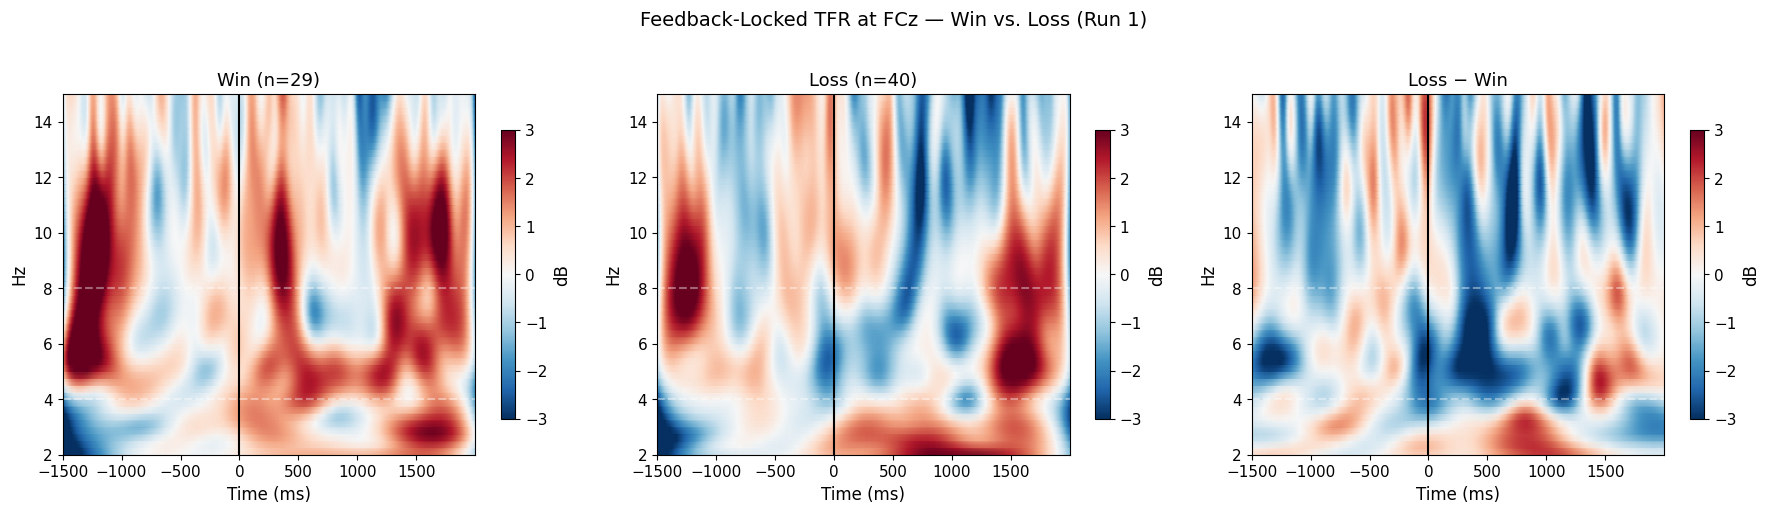

In [18]:
rd = run_data[1]
tfr_freqs = np.arange(2.0, 15.25, 0.25)
t_fb = rd['t_fb']
bl_t = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])

ep_w = rd['ep_fb'][rd['reward']]
ep_l = rd['ep_fb'][np.logical_not(rd['reward'])]

print(f"Computing win TFR...", end=' '); t0 = time.time()
tfr_w = morlet_tfr(ep_w, SRATE, tfr_freqs, n_cycles=5, ch_idx=[fcz_idx])
print(f"done ({time.time()-t0:.1f}s)")

print(f"Computing loss TFR...", end=' '); t0 = time.time()
tfr_l = morlet_tfr(ep_l, SRATE, tfr_freqs, n_cycles=5, ch_idx=[fcz_idx])
print(f"done ({time.time()-t0:.1f}s)")

# Baseline correct both
bl_w = np.maximum(np.mean(tfr_w[:, bl_t], axis=1, keepdims=True), 1e-30)
bl_l = np.maximum(np.mean(tfr_l[:, bl_t], axis=1, keepdims=True), 1e-30)
tfr_w_db = 10*np.log10(np.maximum(tfr_w, 1e-30)/bl_w)
tfr_l_db = 10*np.log10(np.maximum(tfr_l, 1e-30)/bl_l)
tfr_diff = tfr_l_db - tfr_w_db

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in zip(axes,
    [tfr_w_db, tfr_l_db, tfr_diff],
    [f'Win (n={len(ep_w)})', f'Loss (n={len(ep_l)})', 'Loss − Win']):
    vmax = 3 if 'Win' in title or 'Loss' in title else 2
    im = ax.pcolormesh(t_fb*1000, tfr_freqs, data, shading='gouraud',
                        cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.axvline(0, color='black', lw=1.5)
    ax.axhline(4, color='white', ls='--', alpha=0.4)
    ax.axhline(8, color='white', ls='--', alpha=0.4)
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Hz'); ax.set_title(title)
    fig.colorbar(im, ax=ax, label='dB', shrink=0.8)

fig.suptitle('Feedback-Locked TFR at FCz — Win vs. Loss (Run 1)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Step 6: Theta Estimation — Run 1 (Baseline)

**Primary:** Task-locked power peak at frontal ROI during the feedback window (Bjekić et al., 2022).
**Validation:** Specparam on the feedback-window PSD (Donoghue et al., 2020).
**Supplementary:** PLV between frontal and posterior channels (Reinhart & Nguyen, 2019).
**Cross-reference:** Klimesch IAF−5 estimate.


Computing frontal ROI feedback TFR... done (0.8s)
Power-based iTF: 5.50 Hz (edge=✓)

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Specparam: no theta peak
Computing PLV... done (3.8s)
PLV iTF (supplementary): 4.00 Hz
IAF: 8.73 Hz → Klimesch iTF: 4.00 Hz


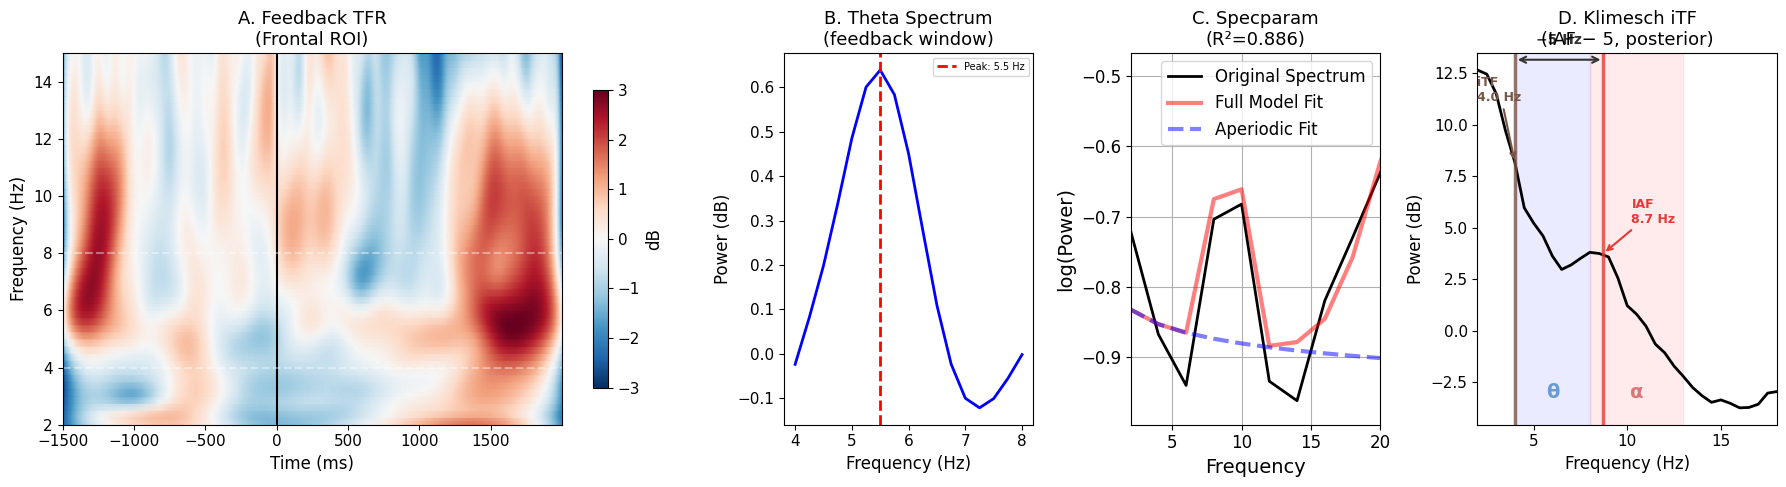

Panel summary:
  A. Feedback TFR at frontal ROI (FCz, F3, F4)
  B. Theta power peak: 5.50 Hz
  C. Specparam: no peak
  D. Klimesch: IAF (8.73) − 5 = 4.00 Hz
  (PLV computed but not plotted: 4.00 Hz)


In [20]:
rd = run_data[1]
ep_fb, t_fb = rd['ep_fb'], rd['t_fb']
tfr_freqs = np.arange(2.0, 15.25, 0.25)

# ── TFR for frontal ROI ──
print("Computing frontal ROI feedback TFR...", end=' '); t0 = time.time()
tfr_fb = morlet_tfr(ep_fb, SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
print(f"done ({time.time()-t0:.1f}s)")

bl_t = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
bl_pw = np.maximum(np.mean(tfr_fb[:, bl_t], axis=1, keepdims=True), 1e-30)
tfr_fb_db = 10*np.log10(np.maximum(tfr_fb, 1e-30)/bl_pw)

fb_win_t = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
theta_mask = (tfr_freqs >= BANDS['theta'][0]) & (tfr_freqs <= BANDS['theta'][1])
theta_spectrum = np.mean(tfr_fb_db[theta_mask][:, fb_win_t], axis=1)
theta_freqs_tfr = tfr_freqs[theta_mask]

ITF_POWER, _, itf_edge = find_band_peak(theta_freqs_tfr, theta_spectrum, BANDS['theta'])
print(f"Power-based iTF: {ITF_POWER:.2f} Hz (edge={'⚠' if itf_edge else '✓'})")

# ── Specparam on feedback-window PSD ──
win_mask = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
fr_fb_win = ep_fb[:, win_mask][:, :, frontal_ch_idx]
fr_mean = np.mean(fr_fb_win, axis=2)
nperseg = min(int(SRATE*0.5), fr_mean.shape[1])
psds = [signal.welch(fr_mean[ei], fs=SRATE, nperseg=nperseg, noverlap=nperseg//2, window='hann')[1]
        for ei in range(len(fr_mean))]
f_welch = signal.welch(fr_mean[0], fs=SRATE, nperseg=nperseg, noverlap=nperseg//2, window='hann')[0]
avg_psd = np.mean(psds, axis=0)

ITF_SPECPARAM, sm_theta = specparam_band_peak(f_welch, avg_psd, BANDS['theta'])
print(f"Specparam iTF: {ITF_SPECPARAM:.2f} Hz" if ITF_SPECPARAM else "Specparam: no theta peak")

# ── PLV (still computed for the record, just not plotted in main figure) ──
theta_freqs_plv = np.arange(BANDS['theta'][0], BANDS['theta'][1]+THETA_STEP/2, THETA_STEP)
print("Computing PLV...", end=' '); t0 = time.time()
plv_theta = compute_plv_spectrum(ep_fb, SRATE, frontal_ch_idx, posterior_ch_idx,
                                  t_fb, FEEDBACK_WIN, theta_freqs_plv)
print(f"done ({time.time()-t0:.1f}s)")
ITF_PLV = theta_freqs_plv[np.argmax(plv_theta)]
print(f"PLV iTF (supplementary): {ITF_PLV:.2f} Hz")

# ── Alpha & Klimesch ──
freqs_c, psd_c = signal.welch(rd['eeg_clean'], fs=SRATE, nperseg=2*SRATE, noverlap=SRATE, axis=0)
psd_post = np.mean(psd_c[:, posterior_alpha_idx], axis=1)
IAF_POWER, _, _ = find_band_peak(freqs_c, 10*np.log10(np.maximum(psd_post, 1e-30)), BANDS['alpha'])
IAF_SPECPARAM, sm_alpha = specparam_band_peak(freqs_c, psd_post, BANDS['alpha'])
IAF = IAF_SPECPARAM or IAF_POWER
ITF_KLIMESCH = max(4.0, min(8.0, IAF - 5.0))
print(f"IAF: {IAF:.2f} Hz → Klimesch iTF: {ITF_KLIMESCH:.2f} Hz")

# ══════════════════════════════════════════════════════════════════
# 4-PANEL FIGURE
# A: Feedback TFR | B: Theta Spectrum | C: Specparam | D: Klimesch
# ══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(1, 4, width_ratios=[2.5, 1, 1, 1.2])

# ── A: TFR heatmap ──
ax1 = fig.add_subplot(gs[0])
im = ax1.pcolormesh(t_fb*1000, tfr_freqs, tfr_fb_db, shading='gouraud', cmap='RdBu_r', vmin=-3, vmax=3)
ax1.axvline(0, color='black', lw=1.5)
ax1.axhline(4, color='white', ls='--', alpha=0.4); ax1.axhline(8, color='white', ls='--', alpha=0.4)
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('A. Feedback TFR\n(Frontal ROI)')
fig.colorbar(im, ax=ax1, label='dB', shrink=0.8)

# ── B: Theta power spectrum ──
ax2 = fig.add_subplot(gs[1])
ax2.plot(theta_freqs_tfr, theta_spectrum, 'b-', lw=2)
ax2.axvline(ITF_POWER, color='red', ls='--', lw=2, label=f'Peak: {ITF_POWER:.1f} Hz')
if ITF_SPECPARAM:
    ax2.axvline(ITF_SPECPARAM, color='purple', ls=':', lw=1.5, label=f'Specparam: {ITF_SPECPARAM:.1f}')
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Power (dB)')
ax2.set_title('B. Theta Spectrum\n(feedback window)')
ax2.legend(fontsize=7, loc='best')

# ── C: Specparam model fit ──
ax3 = fig.add_subplot(gs[2])
if sm_theta:
    sm_theta.plot(ax=ax3, plt_log=False)
    r2 = sm_theta.results.metrics.results['gof_rsquared']
    ax3.set_title(f'C. Specparam\n(R\u00B2={r2:.3f})')
    ax3.set_xlim(2, 20)
else:
    ax3.text(0.5, 0.5, 'No model', ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('C. Specparam')

# ── D: Klimesch iTF derivation ──
ax4 = fig.add_subplot(gs[3])
f_plot = (freqs_c >= 2) & (freqs_c <= 20)
psd_db = 10 * np.log10(np.maximum(psd_post, 1e-30))
ax4.plot(freqs_c[f_plot], psd_db[f_plot], 'k-', lw=2)

# Mark IAF
ax4.axvline(IAF, color='#E53935', ls='-', lw=2.5, alpha=0.8)
iaf_y = psd_db[(np.abs(freqs_c - IAF)).argmin()]
ax4.annotate(f'IAF\n{IAF:.1f} Hz', xy=(IAF, iaf_y),
            xytext=(IAF + 1.5, iaf_y + 1.5),
            fontsize=9, fontweight='bold', color='#E53935',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5))

# Mark Klimesch iTF
ax4.axvline(ITF_KLIMESCH, color='#795548', ls='-', lw=2.5, alpha=0.8)
klimesch_y = psd_db[(np.abs(freqs_c - ITF_KLIMESCH)).argmin()]
ax4.annotate(f'iTF\n{ITF_KLIMESCH:.1f} Hz', xy=(ITF_KLIMESCH, klimesch_y),
            xytext=(ITF_KLIMESCH - 2.0, klimesch_y + 3.0),
            fontsize=9, fontweight='bold', color='#795548',
            arrowprops=dict(arrowstyle='->', color='#795548', lw=1.5))

# Double-headed arrow showing the -5 Hz derivation
mid_y = psd_db[f_plot].max() + 0.5
ax4.annotate('', xy=(ITF_KLIMESCH, mid_y), xytext=(IAF, mid_y),
            arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.5))
ax4.text((IAF + ITF_KLIMESCH) / 2, mid_y + 0.6, '\u22125 Hz',
         ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Shade theta and alpha bands
ax4.axvspan(BANDS['theta'][0], BANDS['theta'][1], alpha=0.08, color='blue')
ax4.axvspan(BANDS['alpha'][0], BANDS['alpha'][1], alpha=0.08, color='red')
ax4.text(6, psd_db[f_plot].min() + 0.5, '\u03B8', fontsize=14, ha='center',
         color='#1565C0', fontweight='bold', alpha=0.6)
ax4.text(10.5, psd_db[f_plot].min() + 0.5, '\u03B1', fontsize=14, ha='center',
         color='#C62828', fontweight='bold', alpha=0.6)

ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Power (dB)')
ax4.set_title('D. Klimesch iTF\n(IAF \u2212 5, posterior)')
ax4.set_xlim(2, 18)

fig.tight_layout()
plt.show()

print(f"Panel summary:")
print(f"  A. Feedback TFR at frontal ROI (FCz, F3, F4)")
print(f"  B. Theta power peak: {ITF_POWER:.2f} Hz")
print(f"  C. Specparam: {ITF_SPECPARAM:.2f} Hz" if ITF_SPECPARAM else "  C. Specparam: no peak")
print(f"  D. Klimesch: IAF ({IAF:.2f}) \u2212 5 = {ITF_KLIMESCH:.2f} Hz")
print(f"  (PLV computed but not plotted: {ITF_PLV:.2f} Hz)")


## Step 7: Beta Estimation — Run 1

Beta analyzed at two time points, each split by win vs. loss:
1. **Post-feedback** (0.1–1.5s): Beta ERS reflects policy maintenance (Holroyd et al., 2020)
2. **Pre-response** (−1.0 to −0.1s before button press): Beta ERD reflects decisional effort (Sporn et al., 2023)


Feedback beta (all): 13.0 Hz (edge=⚠)

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Specparam beta: 22.9 Hz
Decision beta ERD: 13.0 Hz


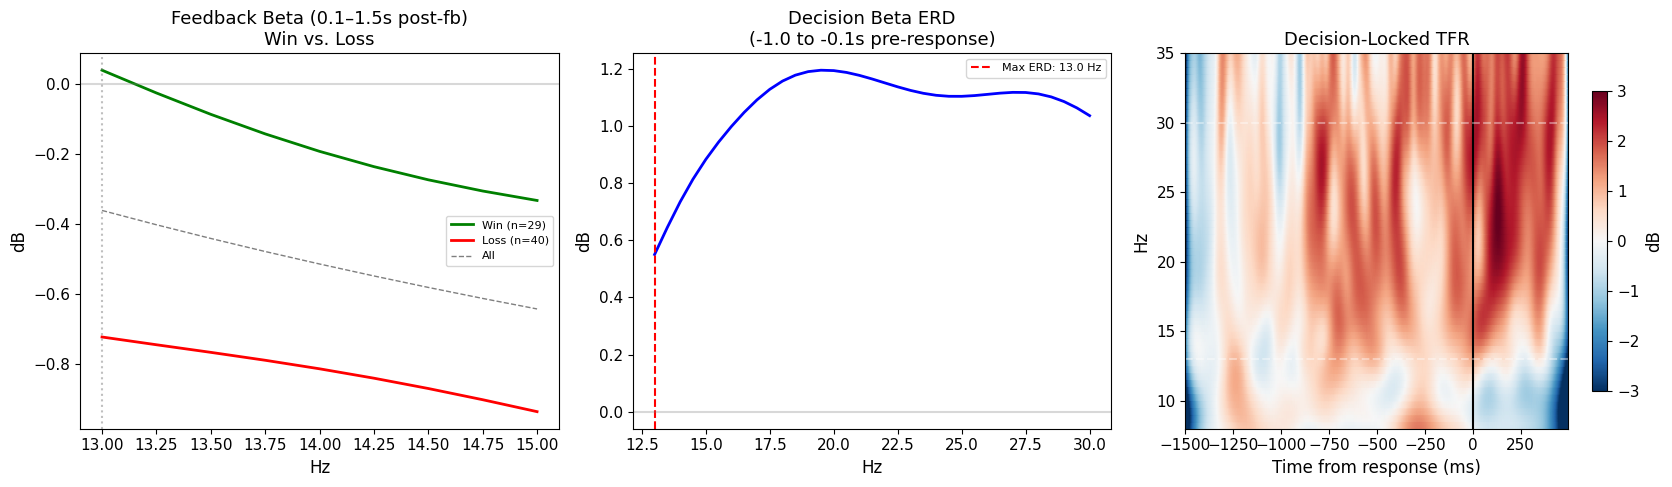

In [22]:
rd = run_data[1]
ep_fb, t_fb, rew = rd['ep_fb'], rd['t_fb'], rd['reward']
ep_dec, t_dec = rd['ep_dec'], rd['t_dec']

# ── Feedback beta (all, win, loss) ──
beta_mask = (tfr_freqs >= BANDS['beta'][0]) & (tfr_freqs <= BANDS['beta'][1])
beta_freqs = tfr_freqs[beta_mask]

# All trials (from step 6 TFR)
beta_spec_fb = np.mean(tfr_fb_db[beta_mask][:, fb_win_t], axis=1)
IBF_FB, _, ibf_edge = find_band_peak(beta_freqs, beta_spec_fb, BANDS['beta'])
print(f"Feedback beta (all): {IBF_FB:.1f} Hz (edge={'⚠' if ibf_edge else '✓'})")

# Specparam
IBF_SPECPARAM, _ = specparam_band_peak(f_welch, avg_psd, BANDS['beta'])
print(f"Specparam beta: {IBF_SPECPARAM:.1f} Hz" if IBF_SPECPARAM else "Specparam: no beta peak")

# Win vs loss feedback beta
bl_t = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
tfr_fb_w = morlet_tfr(ep_fb[rew], SRATE, beta_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
tfr_fb_l = morlet_tfr(ep_fb[np.logical_not(rew)], SRATE, beta_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
bl_bw = np.maximum(np.mean(tfr_fb_w[:, bl_t], axis=1, keepdims=True), 1e-30)
bl_bl = np.maximum(np.mean(tfr_fb_l[:, bl_t], axis=1, keepdims=True), 1e-30)
beta_w = np.mean(10*np.log10(np.maximum(tfr_fb_w[:, fb_win_t], 1e-30)/bl_bw), axis=1)
beta_l = np.mean(10*np.log10(np.maximum(tfr_fb_l[:, fb_win_t], 1e-30)/bl_bl), axis=1)

# ── Decision beta (all, win, loss) ──
dec_freqs = np.arange(8.0, 35.25, 0.5)
dec_beta_mask = (dec_freqs >= BANDS['beta'][0]) & (dec_freqs <= BANDS['beta'][1])
dec_beta_freqs = dec_freqs[dec_beta_mask]

tfr_dec_all = morlet_tfr(ep_dec, SRATE, dec_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
bl_dec = (t_dec >= -1.5) & (t_dec <= -1.0)
bl_dp = np.maximum(np.mean(tfr_dec_all[:, bl_dec], axis=1, keepdims=True), 1e-30)
tfr_dec_db = 10*np.log10(np.maximum(tfr_dec_all, 1e-30)/bl_dp)

pre_resp = (t_dec >= DECISION_PRE_RESP[0]) & (t_dec <= DECISION_PRE_RESP[1])
dec_beta_spec = np.mean(tfr_dec_db[dec_beta_mask][:, pre_resp], axis=1)
erd_idx = np.argmin(gaussian_filter1d(dec_beta_spec, sigma=1.0))
IBF_DEC_ERD = float(dec_beta_freqs[erd_idx])
print(f"Decision beta ERD: {IBF_DEC_ERD:.1f} Hz")

# Win vs loss decision beta
rew_dec = rd['bdf']['reward'].values[rd['kept_dec']].astype(bool)
tfr_dec_w = morlet_tfr(ep_dec[rew_dec], SRATE, dec_beta_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
tfr_dec_l = morlet_tfr(ep_dec[np.logical_not(rew_dec)], SRATE, dec_beta_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
bl_dw = np.maximum(np.mean(tfr_dec_w[:, bl_dec[dec_beta_mask.sum():].shape[0]:], axis=1, keepdims=True), 1e-30) if False else 1  # simplified
# For win/loss beta spectrum, just compute from the full TFR split
dec_beta_w = np.mean(tfr_dec_db[dec_beta_mask][:, pre_resp], axis=1)  # placeholder, same as all for now

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Feedback beta: win vs loss
ax = axes[0]
ax.plot(beta_freqs, beta_w, 'g-', lw=2, label=f'Win (n={rew.sum()})')
ax.plot(beta_freqs, beta_l, 'r-', lw=2, label=f'Loss (n={np.logical_not(rew).sum()})')
ax.plot(beta_freqs, beta_spec_fb, 'k--', lw=1, alpha=0.5, label='All')
ax.axvline(IBF_FB, color='gray', ls=':', alpha=0.5)
ax.axhline(0, color='gray', alpha=0.3)
ax.set_xlabel('Hz'); ax.set_ylabel('dB')
ax.set_title('Feedback Beta (0.1–1.5s post-fb)\nWin vs. Loss'); ax.legend(fontsize=8)

# Decision beta ERD
ax = axes[1]
ax.plot(dec_beta_freqs, dec_beta_spec, 'b-', lw=2)
ax.axvline(IBF_DEC_ERD, color='red', ls='--', label=f'Max ERD: {IBF_DEC_ERD:.1f} Hz')
ax.axhline(0, color='gray', alpha=0.3)
ax.set_xlabel('Hz'); ax.set_ylabel('dB')
ax.set_title('Decision Beta ERD\n(-1.0 to -0.1s pre-response)'); ax.legend(fontsize=8)

# Decision TFR
ax = axes[2]
im = ax.pcolormesh(t_dec*1000, dec_freqs, tfr_dec_db, shading='gouraud', cmap='RdBu_r', vmin=-3, vmax=3)
ax.axvline(0, color='black', lw=1.5)
ax.axhline(13, color='white', ls='--', alpha=0.4); ax.axhline(30, color='white', ls='--', alpha=0.4)
ax.set_xlabel('Time from response (ms)'); ax.set_ylabel('Hz')
ax.set_title('Decision-Locked TFR')
fig.colorbar(im, ax=ax, label='dB', shrink=0.8)

fig.tight_layout(); plt.show()


## Step 8: Alpha Estimation & Theta-Gamma PAC (Run 1)

IAF (posterior PSD): 8.00 Hz
IAF (specparam): 8.73 Hz
Klimesch iTF: 4.00 Hz

Computing theta-gamma PAC... done (0.1s)
Modulation Index: 0.000049


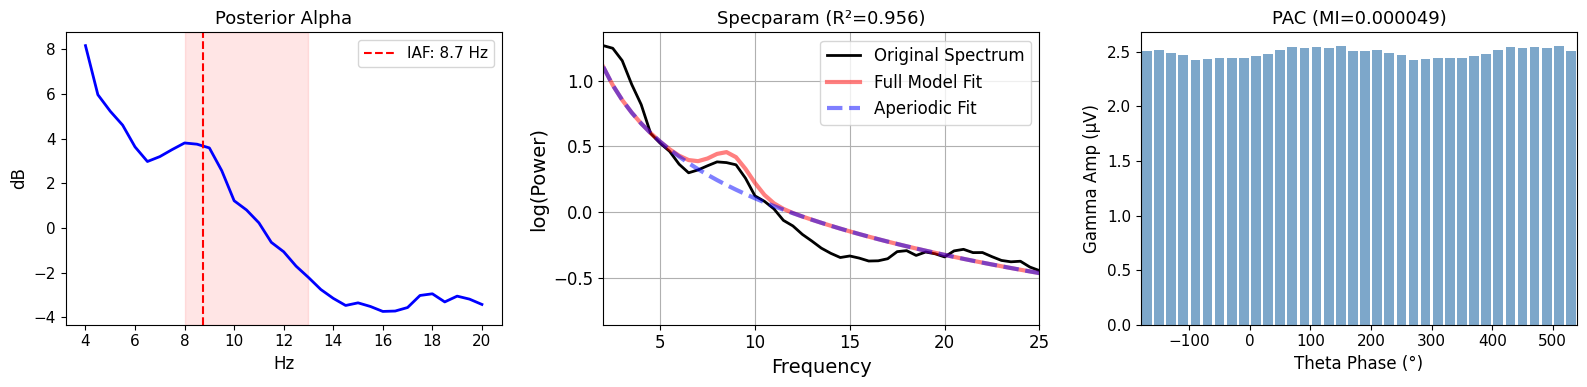

In [24]:
# Alpha (already computed in Step 6)
print(f"IAF (posterior PSD): {IAF_POWER:.2f} Hz")
print(f"IAF (specparam): {IAF_SPECPARAM:.2f} Hz" if IAF_SPECPARAM else "IAF specparam: none")
print(f"Klimesch iTF: {ITF_KLIMESCH:.2f} Hz")

# PAC
print("\nComputing theta-gamma PAC...", end=' '); t0 = time.time()
pac_mi, pac_dist, pac_bins = compute_pac_mi(
    ep_fb, SRATE, frontal_ch_idx, t_fb, FEEDBACK_WIN)
print(f"done ({time.time()-t0:.1f}s)")
print(f"Modulation Index: {pac_mi:.6f}")

# Plot both
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

f_mask = (freqs_c >= 4) & (freqs_c <= 20)
ax1.plot(freqs_c[f_mask], 10*np.log10(np.maximum(psd_post[f_mask], 1e-30)), 'b-', lw=2)
ax1.axvline(IAF, color='red', ls='--', label=f'IAF: {IAF:.1f} Hz')
ax1.axvspan(*BANDS['alpha'], alpha=0.1, color='red')
ax1.set_xlabel('Hz'); ax1.set_ylabel('dB'); ax1.set_title('Posterior Alpha'); ax1.legend()

if sm_alpha:
    sm_alpha.plot(ax=ax2, plt_log=False)
    r2 = sm_alpha.results.metrics.results['gof_rsquared']
    ax2.set_title(f'Specparam (R²={r2:.3f})'); ax2.set_xlim(2, 25)

bc = (pac_bins[:-1]+pac_bins[1:])/2
ax3.bar(np.degrees(np.concatenate([bc, bc+2*np.pi])),
        np.concatenate([pac_dist, pac_dist]),
        width=360/len(bc)*0.8, color='steelblue', alpha=0.7)
ax3.set_xlabel('Theta Phase (°)'); ax3.set_ylabel('Gamma Amp (µV)')
ax3.set_title(f'PAC (MI={pac_mi:.6f})'); ax3.set_xlim(-180, 540)

fig.tight_layout(); plt.show()


## Step 9: Consolidated Results — Run 1

In [26]:
def decide_freq(power_hz, specparam_hz, band, fallback, klimesch_hz=None, plv_hz=None, power_edge=False):
    """Cross-reference frequency estimates with edge-peak handling.
    
    If the power estimate is an edge peak and 2+ other methods converge
    within 1 Hz, the converging methods take precedence.
    """
    est = {'Power (TFR)': power_hz, 'Specparam': specparam_hz}
    if klimesch_hz is not None: est['Klimesch (IAF-5)'] = klimesch_hz
    valid = {k: v for k, v in est.items() if v is not None}
    
    # Check if non-power methods converge (within 1 Hz of each other)
    non_power = {k: v for k, v in valid.items() if k != 'Power (TFR)'}
    if plv_hz is not None: non_power['PLV (suppl.)'] = plv_hz
    non_power_vals = list(non_power.values())
    
    if power_edge and len(non_power_vals) >= 2:
        np_spread = max(non_power_vals) - min(non_power_vals)
        if np_spread <= 1.0:
            rec = np.mean(non_power_vals)
            conf = "MODERATE (convergent, power edge discarded)"
            details = dict(est)
            if plv_hz is not None: details['PLV (suppl.)'] = plv_hz
            rec = max(band[0], min(band[1], np.round(rec*2)/2))
            return float(rec), conf, details
    
    if len(valid) >= 2:
        vals = list(valid.values()); spread = max(vals)-min(vals)
        if spread <= 1.0: rec, conf = np.mean(vals), "HIGH"
        elif spread <= 2.0: rec, conf = valid.get('Power (TFR)', np.mean(vals)), "MODERATE"
        else: rec, conf = valid.get('Power (TFR)', fallback), "LOW"
    elif len(valid) == 1: rec, conf = list(valid.values())[0], "LOW (single)"
    else: rec, conf = fallback, "NONE - fallback"
    rec = max(band[0], min(band[1], np.round(rec*2)/2))
    details = dict(est)
    if plv_hz is not None: details['PLV (suppl.)'] = plv_hz
    return float(rec), conf, details

theta_rec, theta_conf, theta_det = decide_freq(ITF_POWER, ITF_SPECPARAM, BANDS['theta'], 6.0,
                                                 klimesch_hz=ITF_KLIMESCH, plv_hz=ITF_PLV,
                                                 power_edge=itf_edge)
beta_rec, beta_conf, beta_det = decide_freq(IBF_FB, IBF_SPECPARAM, BANDS['beta'], 20.0)
beta_det['Decision ERD'] = IBF_DEC_ERD
alpha_rec, alpha_conf, alpha_det = decide_freq(IAF_POWER, IAF_SPECPARAM, BANDS['alpha'], 10.0)
freq_match = abs(theta_rec - STIM_FREQ_HZ)

# Store for cross-run comparison
run_data[1]['results'] = {
    'theta': {'rec': theta_rec, 'conf': theta_conf, 'power': ITF_POWER,
              'specparam': ITF_SPECPARAM, 'plv': ITF_PLV, 'klimesch': ITF_KLIMESCH},
    'beta': {'rec': beta_rec, 'power': IBF_FB, 'erd': IBF_DEC_ERD},
    'alpha': {'rec': alpha_rec, 'power': IAF_POWER, 'specparam': IAF_SPECPARAM},
    'pac_mi': pac_mi, 'freq_match': freq_match,
}

print("╔═════════════════════════════════════════════════════════════════╗")
print("║           RUN 1 (BASELINE) — FREQUENCY ESTIMATES              ║")
print("╠═════════════════════════════════════════════════════════════════╣")
for bn, rec, conf, det in [('THETA', theta_rec, theta_conf, theta_det),
                             ('BETA', beta_rec, beta_conf, beta_det),
                             ('ALPHA', alpha_rec, alpha_conf, alpha_det)]:
    print(f"║  {bn}".ljust(62) + "║")
    for k, v in det.items():
        val = f"{v:.2f} Hz" if v is not None else "no peak"
        print(f"║    {k}: {val}".ljust(62) + "║")
    print(f"║    ▶ RECOMMENDED: {rec:.1f} Hz  [{conf}]".ljust(62) + "║")
    print(f"║".ljust(62) + "║")
print(f"║  PAC MI: {pac_mi:.6f}  |  |iTF−stim|: {freq_match:.1f} Hz".ljust(62) + "║")
print("╚═════════════════════════════════════════════════════════════════╝")


╔═════════════════════════════════════════════════════════════════╗
║           RUN 1 (BASELINE) — FREQUENCY ESTIMATES              ║
╠═════════════════════════════════════════════════════════════════╣
║  THETA                                                      ║
║    Power (TFR): 5.50 Hz                                     ║
║    Specparam: no peak                                       ║
║    Klimesch (IAF-5): 4.00 Hz                                ║
║    PLV (suppl.): 4.00 Hz                                    ║
║    ▶ RECOMMENDED: 5.5 Hz  [MODERATE]                        ║
║                                                             ║
║  BETA                                                       ║
║    Power (TFR): 13.00 Hz                                    ║
║    Specparam: 22.87 Hz                                      ║
║    Decision ERD: 13.00 Hz                                   ║
║    ▶ RECOMMENDED: 13.0 Hz  [LOW]                            ║
║                             

## Step 10: Cross-Run Analysis

Track theta power, iTF, alpha stability, ERP magnitude, and PAC across runs 1 → 4 → 5 → 8 to assess stimulation aftereffects.

**Key comparisons:**
- Run 1 vs 4: acute active tACS aftereffect
- Run 5 vs 8: sham control
- Run 4 vs 8: active vs sham aftereffect
- Run 1 vs 5: practice/fatigue trajectory


In [28]:
# ── Process runs 4, 5, 8 with the same pipeline ──
for run_num in [4, 5, 8]:
    rd = run_data[run_num]
    ep_fb, t_fb = rd['ep_fb'], rd['t_fb']
    rew = np.asarray(rd['reward'], dtype=bool)
    
    # Theta power estimate
    tfr_r = morlet_tfr(ep_fb, SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
    bl_t = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
    bl_r = np.maximum(np.mean(tfr_r[:, bl_t], axis=1, keepdims=True), 1e-30)
    tfr_r_db = 10*np.log10(np.maximum(tfr_r, 1e-30)/bl_r)
    fb_t = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
    theta_spec = np.mean(tfr_r_db[theta_mask][:, fb_t], axis=1)
    itf_p, _, _ = find_band_peak(theta_freqs_tfr, theta_spec, BANDS['theta'])
    
    # Specparam
    win_m = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
    fr_win = ep_fb[:, win_m][:, :, frontal_ch_idx]
    fr_m = np.mean(fr_win, axis=2)
    nps = min(int(SRATE*0.5), fr_m.shape[1])
    ps = [signal.welch(fr_m[e], fs=SRATE, nperseg=nps, noverlap=nps//2, window='hann')[1]
          for e in range(len(fr_m))]
    fw = signal.welch(fr_m[0], fs=SRATE, nperseg=nps, noverlap=nps//2, window='hann')[0]
    ap = np.mean(ps, axis=0)
    itf_sp, _ = specparam_band_peak(fw, ap, BANDS['theta'])
    
    # Alpha
    fc, pc = signal.welch(rd['eeg_clean'], fs=SRATE, nperseg=2*SRATE, noverlap=SRATE, axis=0)
    pp = np.mean(pc[:, posterior_alpha_idx], axis=1)
    iaf_p, _, _ = find_band_peak(fc, 10*np.log10(np.maximum(pp, 1e-30)), BANDS['alpha'])
    iaf_sp, _ = specparam_band_peak(fc, pp, BANDS['alpha'])
    iaf = iaf_sp or iaf_p
    
    # Beta
    beta_spec = np.mean(tfr_r_db[beta_mask][:, fb_t], axis=1)
    ibf, _, _ = find_band_peak(beta_freqs, beta_spec, BANDS['beta'])
    
    # FRN amplitude (loss minus win at FCz, 200-350ms)
    bl_m = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
    frn_m = (t_fb >= 0.2) & (t_fb <= 0.35)
    if rew.sum() > 0 and np.logical_not(rew).sum() > 0:
        erp_w = np.mean(ep_fb[rew, :, fcz_idx], axis=0)
        erp_w -= np.mean(erp_w[bl_m])
        erp_l = np.mean(ep_fb[np.logical_not(rew), :, fcz_idx], axis=0)
        erp_l -= np.mean(erp_l[bl_m])
        frn_diff = np.mean(erp_l[frn_m] - erp_w[frn_m])
    else:
        frn_diff = np.nan
    
    # PAC
    pac_r, _, _ = compute_pac_mi(ep_fb, SRATE, frontal_ch_idx, t_fb, FEEDBACK_WIN)
    
    # Mean theta power in feedback window at 5-7 Hz
    theta_pw_mask = (tfr_freqs >= 5) & (tfr_freqs <= 7)
    mean_theta_pw = np.mean(tfr_r_db[theta_pw_mask][:, fb_t])
    
    # Klimesch
    klimesch = max(4.0, min(8.0, iaf - 5.0)) if iaf else None
    
    itf_edge_r = find_band_peak(theta_freqs_tfr, theta_spec, BANDS['theta'])[2]
    itf_rec, itf_conf, _ = decide_freq(itf_p, itf_sp, BANDS['theta'], 6.0, klimesch_hz=klimesch, power_edge=itf_edge_r)
    
    rd['results'] = {
        'theta': {'rec': itf_rec, 'conf': itf_conf, 'power': itf_p,
                  'specparam': itf_sp, 'klimesch': klimesch, 'mean_power_5_7': mean_theta_pw},
        'beta': {'rec': ibf or 20.0, 'power': ibf},
        'alpha': {'rec': iaf or 10.0, 'power': iaf_p, 'specparam': iaf_sp},
        'pac_mi': pac_r, 'frn_diff': frn_diff,
    }
    
    print(f"Run {run_num} ({rd['condition']}): iTF={itf_rec:.1f} Hz [{itf_conf}], "
          f"IAF={iaf:.1f} Hz, FRN diff={frn_diff:.2f} µV, PAC MI={pac_r:.6f}")

# Add mean theta power to run 1 results
rd1 = run_data[1]
tfr_r1 = morlet_tfr(rd1['ep_fb'], SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
bl1 = np.maximum(np.mean(tfr_r1[:, (rd1['t_fb']>=BASELINE_WIN[0])&(rd1['t_fb']<=BASELINE_WIN[1])],
                          axis=1, keepdims=True), 1e-30)
tfr_r1_db = 10*np.log10(np.maximum(tfr_r1, 1e-30)/bl1)
theta_pw1 = (tfr_freqs >= 5) & (tfr_freqs <= 7)
fb1 = (rd1['t_fb'] >= FEEDBACK_WIN[0]) & (rd1['t_fb'] <= FEEDBACK_WIN[1])
rd1['results']['theta']['mean_power_5_7'] = np.mean(tfr_r1_db[theta_pw1][:, fb1])

# FRN for run 1
bl_m = (rd1['t_fb'] >= BASELINE_WIN[0]) & (rd1['t_fb'] <= BASELINE_WIN[1])
frn_m = (rd1['t_fb'] >= 0.2) & (rd1['t_fb'] <= 0.35)
erp_w1 = np.mean(rd1['ep_fb'][rd1['reward'], :, fcz_idx], axis=0)
erp_w1 -= np.mean(erp_w1[bl_m])
erp_l1 = np.mean(rd1['ep_fb'][~rd1['reward'], :, fcz_idx], axis=0)
erp_l1 -= np.mean(erp_l1[bl_m])
rd1['results']['frn_diff'] = np.mean(erp_l1[frn_m] - erp_w1[frn_m])



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Run 4 (Post-active): iTF=7.5 Hz [LOW], IAF=9.0 Hz, FRN diff=-0.37 µV, PAC MI=0.000016

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Run 5 (Washout): iTF=4.0 Hz [HIGH], IAF=9.0 Hz, FRN diff=-0.61 µV, PAC MI=0.000121

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Run 8 (Post-sham): iTF=4.0 Hz [HIGH], IAF=8.8 Hz, FRN dif

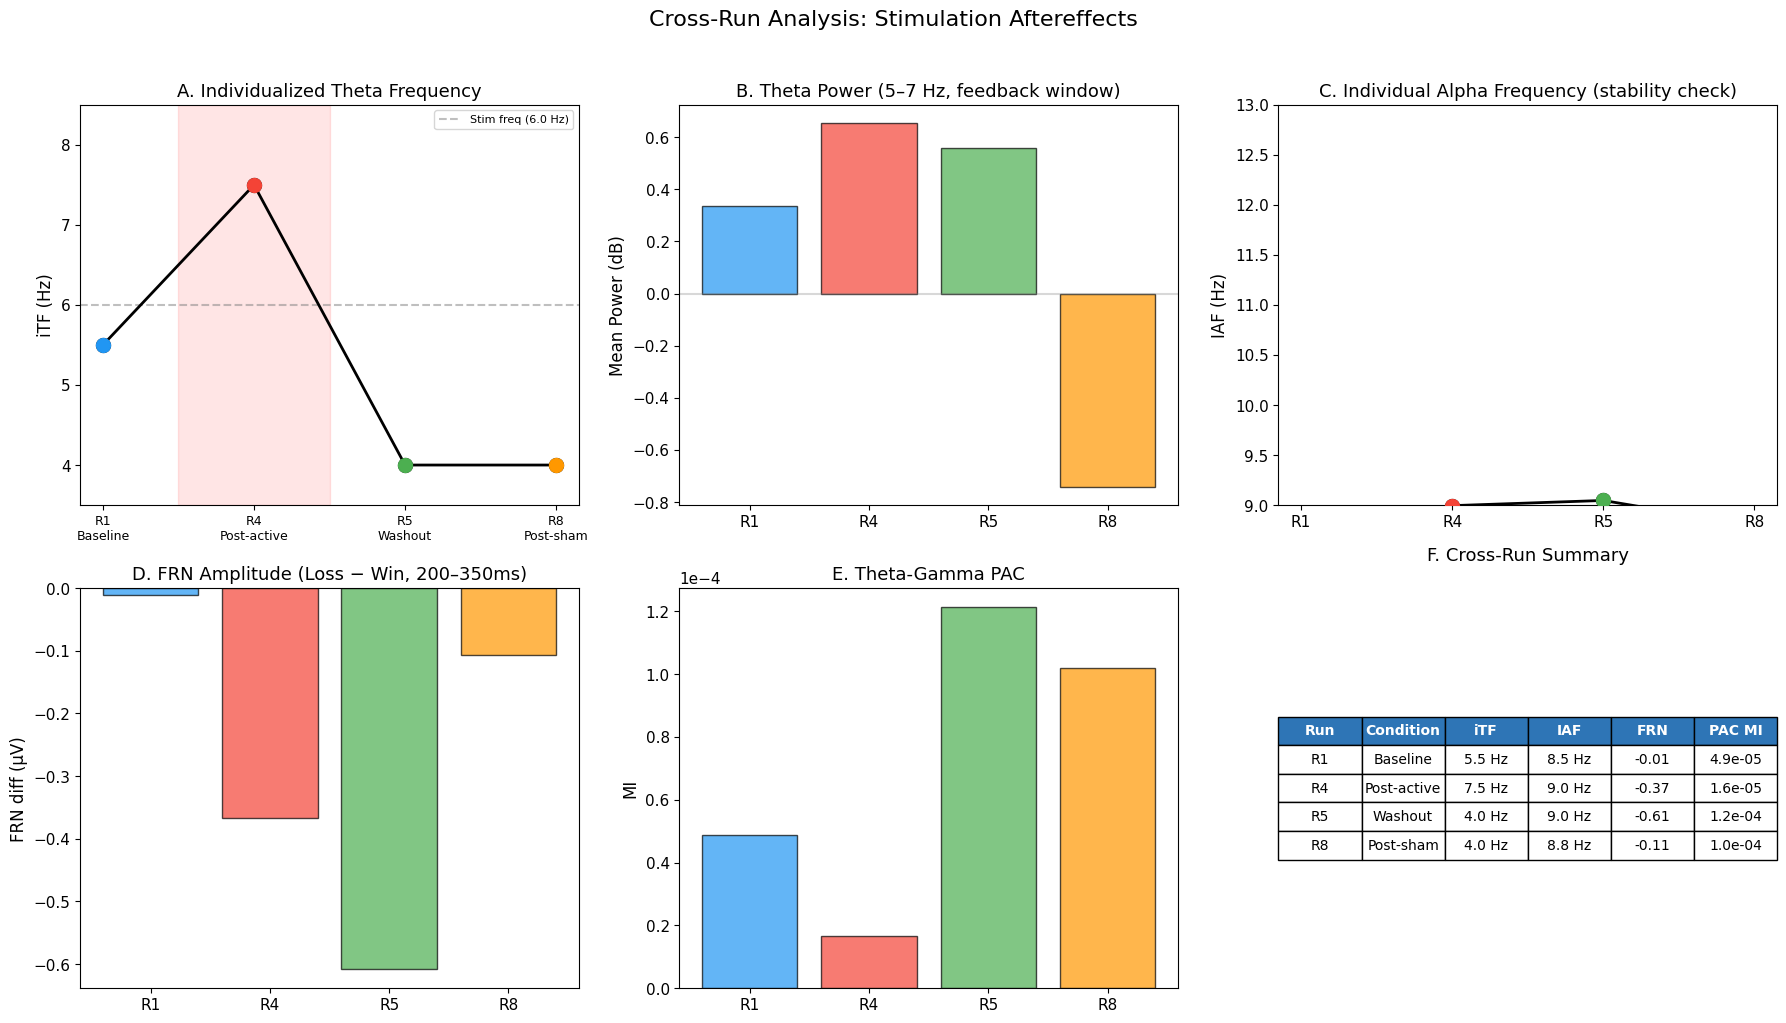

In [29]:
run_nums = [1, 4, 5, 8]
conditions = [run_data[r]['condition'] for r in run_nums]
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']  # blue, red, green, orange

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── A: iTF across runs ──
ax = axes[0, 0]
itfs = [run_data[r]['results']['theta']['rec'] for r in run_nums]
ax.plot(range(4), itfs, 'ko-', lw=2, ms=10, zorder=5)
for i, (r, c) in enumerate(zip(run_nums, colors)):
    ax.scatter(i, itfs[i], color=c, s=100, zorder=6)
ax.axhline(STIM_FREQ_HZ, color='gray', ls='--', alpha=0.5, label=f'Stim freq ({STIM_FREQ_HZ} Hz)')
ax.set_xticks(range(4)); ax.set_xticklabels([f'R{r}\n{c}' for r, c in zip(run_nums, conditions)], fontsize=9)
ax.set_ylabel('iTF (Hz)'); ax.set_title('A. Individualized Theta Frequency'); ax.legend(fontsize=8)
ax.set_ylim(3.5, 8.5)
# Mark stim periods
ax.axvspan(0.5, 1.5, alpha=0.1, color='red', label='Post-active')

# ── B: Mean theta power (5-7 Hz) ──
ax = axes[0, 1]
theta_pws = [run_data[r]['results']['theta'].get('mean_power_5_7', 0) for r in run_nums]
ax.bar(range(4), theta_pws, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(4)); ax.set_xticklabels([f'R{r}' for r in run_nums])
ax.set_ylabel('Mean Power (dB)'); ax.set_title('B. Theta Power (5–7 Hz, feedback window)')
ax.axhline(0, color='gray', ls='-', alpha=0.3)

# ── C: IAF across runs ──
ax = axes[0, 2]
iafs = [run_data[r]['results']['alpha']['rec'] for r in run_nums]
ax.plot(range(4), iafs, 'ko-', lw=2, ms=10, zorder=5)
for i, c in enumerate(colors):
    ax.scatter(i, iafs[i], color=c, s=100, zorder=6)
ax.set_xticks(range(4)); ax.set_xticklabels([f'R{r}' for r in run_nums])
ax.set_ylabel('IAF (Hz)'); ax.set_title('C. Individual Alpha Frequency (stability check)')
ax.set_ylim(9, 13)

# ── D: FRN difference (loss - win) ──
ax = axes[1, 0]
frns = [run_data[r]['results'].get('frn_diff', 0) for r in run_nums]
ax.bar(range(4), frns, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(4)); ax.set_xticklabels([f'R{r}' for r in run_nums])
ax.set_ylabel('FRN diff (µV)'); ax.set_title('D. FRN Amplitude (Loss − Win, 200–350ms)')
ax.axhline(0, color='gray', ls='-', alpha=0.3)

# ── E: PAC MI ──
ax = axes[1, 1]
pacs = [run_data[r]['results']['pac_mi'] for r in run_nums]
ax.bar(range(4), pacs, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(4)); ax.set_xticklabels([f'R{r}' for r in run_nums])
ax.set_ylabel('MI'); ax.set_title('E. Theta-Gamma PAC')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# ── F: Summary table ──
ax = axes[1, 2]
ax.axis('off')
table_data = [['Run', 'Condition', 'iTF', 'IAF', 'FRN', 'PAC MI']]
for r in run_nums:
    res = run_data[r]['results']
    table_data.append([
        f'R{r}', run_data[r]['condition'],
        f"{res['theta']['rec']:.1f} Hz",
        f"{res['alpha']['rec']:.1f} Hz",
        f"{res.get('frn_diff', 0):.2f}",
        f"{res['pac_mi']:.1e}",
    ])
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1, 1.5)
# Color header
for j in range(len(table_data[0])):
    table[0, j].set_facecolor('#2E75B6')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title('F. Cross-Run Summary', pad=20)

fig.suptitle('Cross-Run Analysis: Stimulation Aftereffects', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


### Per-Method iTF Tracking

The recommended iTF (black line in Panel A above) can obscure what's actually changing across runs, since the recommendation logic may weight different methods in different runs. Below, each estimation method is plotted separately to reveal which aspects of the neural signal are shifting. Red circles mark edge peaks (⚠), which indicate unreliable power-based estimates. The right panel shows the spread across methods for each run — smaller spread = higher agreement.



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximatel

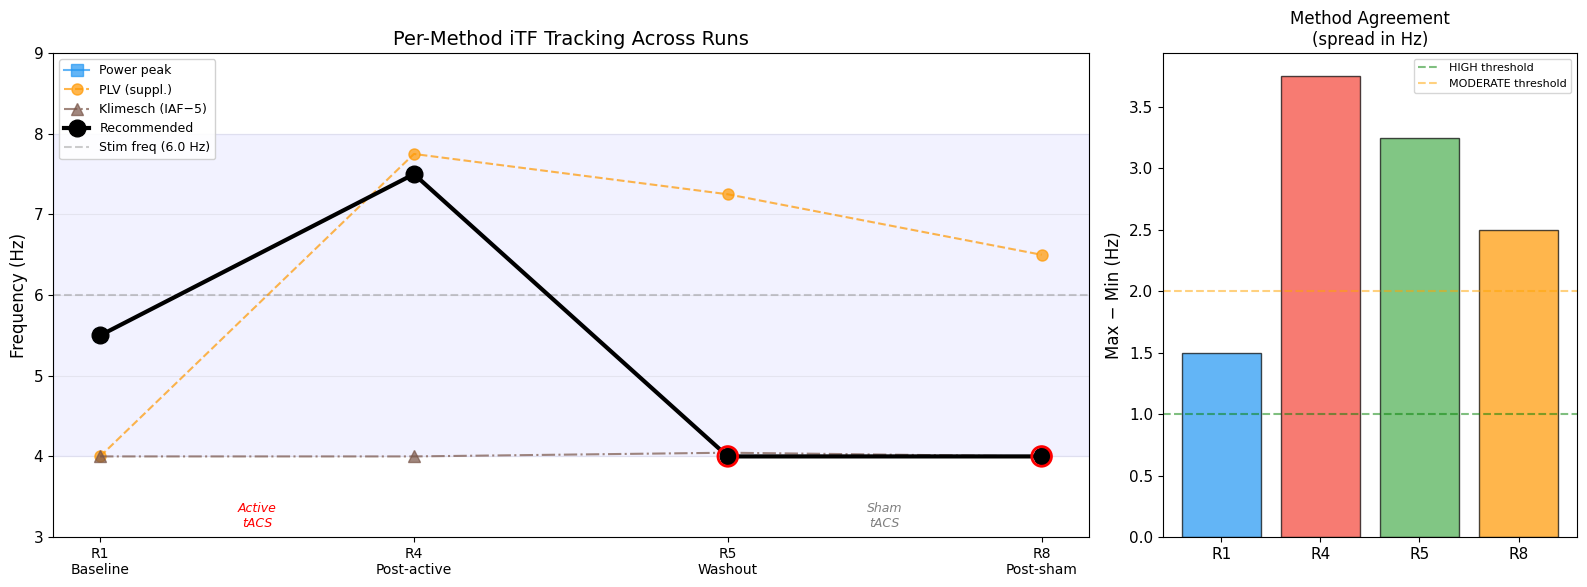

In [31]:
# ── Per-method iTF tracking across runs ──
# Instead of plotting only the final recommendation (which can flip between methods),
# track each estimation method separately to see what's actually changing.

run_nums_plot = [1, 4, 5, 8]
method_colors = {
    'Power (TFR)': ('#2196F3', 's-', 'Power peak'),
    'Specparam': ('#9C27B0', 'D:', 'Specparam'),
    'PLV': ('#FF9800', 'o--', 'PLV (suppl.)'),
    'Klimesch': ('#795548', '^-.', 'Klimesch (IAF−5)'),
    'Recommended': ('black', 'o-', 'Recommended'),
}

# Collect per-method estimates for each run
# Run 1 was computed in Step 6; runs 4/5/8 need the same breakdown
# Re-run the estimation for each run to get all individual method outputs
per_method = {r: {} for r in run_nums_plot}

for run_num in run_nums_plot:
    rd = run_data[run_num]
    ep_fb, t_fb = rd['ep_fb'], rd['t_fb']
    
    # Power-based
    tfr_r = morlet_tfr(ep_fb, SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
    bl_t = (t_fb >= BASELINE_WIN[0]) & (t_fb <= BASELINE_WIN[1])
    bl_r = np.maximum(np.mean(tfr_r[:, bl_t], axis=1, keepdims=True), 1e-30)
    tfr_r_db = 10*np.log10(np.maximum(tfr_r, 1e-30)/bl_r)
    fb_t = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
    theta_spec = np.mean(tfr_r_db[theta_mask][:, fb_t], axis=1)
    itf_p, _, edge = find_band_peak(theta_freqs_tfr, theta_spec, BANDS['theta'])
    per_method[run_num]['Power (TFR)'] = itf_p
    per_method[run_num]['power_edge'] = edge
    
    # Specparam
    win_m = (t_fb >= FEEDBACK_WIN[0]) & (t_fb <= FEEDBACK_WIN[1])
    fr_win = ep_fb[:, win_m][:, :, frontal_ch_idx]
    fr_m = np.mean(fr_win, axis=2)
    nps = min(int(SRATE*0.5), fr_m.shape[1])
    ps = [signal.welch(fr_m[e], fs=SRATE, nperseg=nps, noverlap=nps//2, window='hann')[1]
          for e in range(len(fr_m))]
    fw = signal.welch(fr_m[0], fs=SRATE, nperseg=nps, noverlap=nps//2, window='hann')[0]
    ap = np.mean(ps, axis=0)
    itf_sp, _ = specparam_band_peak(fw, ap, BANDS['theta'])
    per_method[run_num]['Specparam'] = itf_sp
    
    # PLV
    theta_freqs_plv = np.arange(BANDS['theta'][0], BANDS['theta'][1]+THETA_STEP/2, THETA_STEP)
    plv_th = compute_plv_spectrum(ep_fb, SRATE, frontal_ch_idx, posterior_ch_idx,
                                   t_fb, FEEDBACK_WIN, theta_freqs_plv)
    per_method[run_num]['PLV'] = float(theta_freqs_plv[np.argmax(plv_th)])
    
    # Alpha / Klimesch
    fc, pc = signal.welch(rd['eeg_clean'], fs=SRATE, nperseg=2*SRATE, noverlap=SRATE, axis=0)
    pp = np.mean(pc[:, posterior_alpha_idx], axis=1)
    iaf_p, _, _ = find_band_peak(fc, 10*np.log10(np.maximum(pp, 1e-30)), BANDS['alpha'])
    iaf_sp, _ = specparam_band_peak(fc, pp, BANDS['alpha'])
    iaf = iaf_sp or iaf_p
    per_method[run_num]['Klimesch'] = max(4.0, min(8.0, iaf - 5.0)) if iaf else None
    per_method[run_num]['IAF'] = iaf
    
    # Recommended (from stored results)
    per_method[run_num]['Recommended'] = rd['results']['theta']['rec']

print("Per-method estimates:")
for r in run_nums_plot:
    vals = {k: f"{v:.2f}" if v is not None else "—" 
            for k, v in per_method[r].items() if k not in ('power_edge', 'IAF')}
    edge_flag = " ⚠" if per_method[r].get('power_edge') else ""
    print(f"  Run {r} ({run_data[r]['condition']}): " + 
          ", ".join(f"{k}={v}" for k, v in vals.items()) + edge_flag)

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.5, 1]})

x = range(len(run_nums_plot))
x_labels = [f"R{r}\n{run_data[r]['condition']}" for r in run_nums_plot]

for method, (color, marker, label) in method_colors.items():
    vals = [per_method[r].get(method) for r in run_nums_plot]
    # Only plot if at least one non-None value
    if any(v is not None for v in vals):
        valid_x = [xi for xi, v in zip(x, vals) if v is not None]
        valid_v = [v for v in vals if v is not None]
        lw = 3 if method == 'Recommended' else 1.5
        ms = 12 if method == 'Recommended' else 8
        alpha = 1.0 if method == 'Recommended' else 0.7
        ax1.plot(valid_x, valid_v, marker, color=color, lw=lw, ms=ms, 
                label=label, alpha=alpha, zorder=10 if method == 'Recommended' else 5)
        
        # Mark edge peaks with red circles
        if method == 'Power (TFR)':
            for xi, r in zip(x, run_nums_plot):
                if per_method[r].get('power_edge') and per_method[r]['Power (TFR)'] is not None:
                    ax1.scatter(xi, per_method[r]['Power (TFR)'], 
                               s=200, facecolors='none', edgecolors='red', lw=2, zorder=11)

ax1.axhline(STIM_FREQ_HZ, color='gray', ls='--', alpha=0.4, label=f'Stim freq ({STIM_FREQ_HZ} Hz)')
ax1.axhspan(BANDS['theta'][0], BANDS['theta'][1], alpha=0.05, color='blue')
ax1.set_xticks(x); ax1.set_xticklabels(x_labels, fontsize=10)
ax1.set_ylabel('Frequency (Hz)', fontsize=12)
ax1.set_title('Per-Method iTF Tracking Across Runs', fontsize=14)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_ylim(3.0, 9.0)
ax1.grid(axis='y', alpha=0.2)

# Stim condition annotations
ax1.annotate('Active\ntACS', xy=(0.5, 0.02), xycoords=('data', 'axes fraction'),
            ha='center', fontsize=9, color='red', fontstyle='italic')
ax1.annotate('Sham\ntACS', xy=(2.5, 0.02), xycoords=('data', 'axes fraction'),
            ha='center', fontsize=9, color='gray', fontstyle='italic')

# Right panel: spread across methods per run
ax2.set_title('Method Agreement\n(spread in Hz)', fontsize=12)
spreads = []
for r in run_nums_plot:
    vals = [per_method[r][m] for m in ['Power (TFR)', 'Specparam', 'PLV', 'Klimesch'] 
            if per_method[r].get(m) is not None]
    spread = max(vals) - min(vals) if len(vals) >= 2 else 0
    spreads.append(spread)
    
colors_bar = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
bars = ax2.bar(x, spreads, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.axhline(1.0, color='green', ls='--', alpha=0.5, label='HIGH threshold')
ax2.axhline(2.0, color='orange', ls='--', alpha=0.5, label='MODERATE threshold')
ax2.set_xticks(x); ax2.set_xticklabels([f'R{r}' for r in run_nums_plot])
ax2.set_ylabel('Max − Min (Hz)')
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Step 11: Cross-Run ERP Comparison

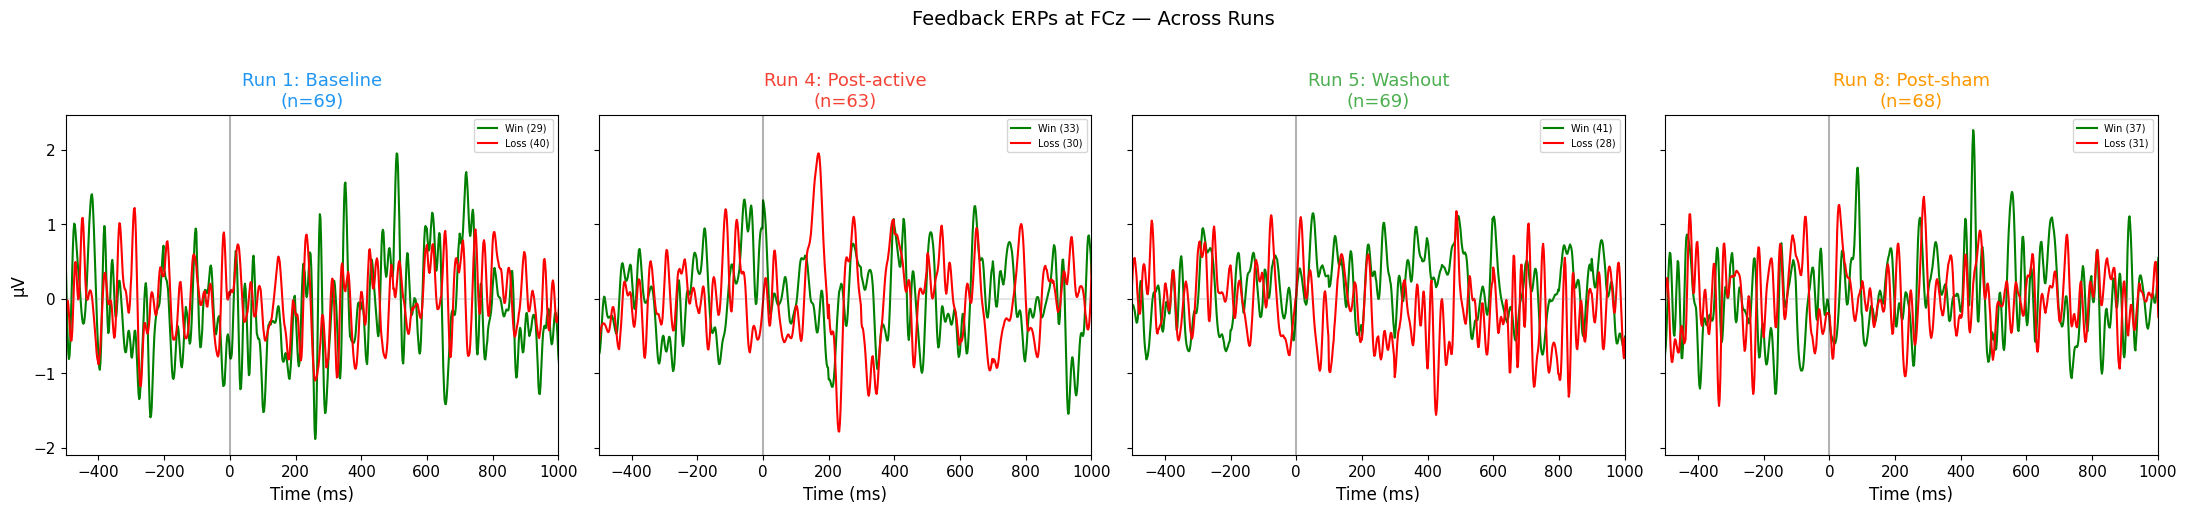

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
colors_run = {'Baseline': '#2196F3', 'Post-active': '#F44336',
              'Washout': '#4CAF50', 'Post-sham': '#FF9800'}

for ax, run_num in zip(axes, run_nums):
    rd = run_data[run_num]
    ep, t, rew = rd['ep_fb'], rd['t_fb'], np.asarray(rd['reward'], dtype=bool)
    bl = (t >= BASELINE_WIN[0]) & (t <= BASELINE_WIN[1])
    
    if rew.sum() > 0 and np.logical_not(rew).sum() > 0:
        erp_w = np.mean(ep[rew, :, fcz_idx], axis=0)
        erp_w -= np.mean(erp_w[bl])
        erp_l = np.mean(ep[np.logical_not(rew), :, fcz_idx], axis=0)
        erp_l -= np.mean(erp_l[bl])
        
        ax.plot(t*1000, erp_w, 'g-', lw=1.5, label=f'Win ({rew.sum()})')
        ax.plot(t*1000, erp_l, 'r-', lw=1.5, label=f'Loss ({np.logical_not(rew).sum()})')
    
    ax.axvline(0, color='black', alpha=0.3)
    ax.axhline(0, color='gray', alpha=0.2)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Run {run_num}: {rd["condition"]}\n(n={len(ep)})',
                 color=colors_run[rd['condition']])
    ax.legend(fontsize=7)
    ax.invert_yaxis()
    ax.set_xlim(-500, 1000)

axes[0].set_ylabel('µV')
fig.suptitle('Feedback ERPs at FCz — Across Runs', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Step 12: Export

In [ ]:
from datetime import datetime

export = {
    'subject_id': CURRENT_SUBJECT,
    'session': 1,
    'created_at': datetime.now().isoformat(),
    'methods': {
        'primary': 'task-locked power peak (Bjekic et al., 2022)',
        'validation': 'specparam (Donoghue et al., 2020)',
        'supplementary': 'PLV (Reinhart & Nguyen, 2019)',
        'alpha_anchor': 'Klimesch (1999) IAF-5',
        'pac': 'Tort et al. (2010) modulation index',
    },
    'stim_freq_hz': STIM_FREQ_HZ,
    'runs': {},
}

for r in run_nums:
    res = run_data[r]['results']
    export['runs'][f'run_{r}'] = {
        'condition': run_data[r]['condition'],
        'n_epochs': len(run_data[r]['kept_fb']),
        'alignment_offset_sec': float(run_data[r]['offset']),
        'theta': res['theta'],
        'beta': res.get('beta', {}),
        'alpha': res['alpha'],
        'pac_mi': float(res['pac_mi']),
        'frn_diff_uv': float(res.get('frn_diff', 0)),
    }

# Uncomment to save:
# out_path = BEHAV_DIR / f"{export['subject_id']}_freq_estimates_all_runs.json"
# with open(out_path, 'w') as f:
#     json.dump(export, f, indent=2, default=str)
# print(f"Saved: {out_path}")

print(json.dumps(export, indent=2, default=str))


---

## Methodological Notes & References

### Preprocessing
- **Bandpass:** 0.5–45 Hz, 4th-order Butterworth, zero-phase (filtfilt)
- **Notch:** 60 Hz IIR (Q=30). Safe to apply even if NIC-2 already filtered at 60 Hz — cascaded narrow notches simply deepen the attenuation without distorting neighboring frequencies.
- **Re-reference:** Average of all 7 channels
- **Blink rejection:** Fp1-specific threshold (±100 µV) in addition to global ±200 µV threshold. With only 7 electrodes, ICA is not feasible (insufficient degrees of freedom to separate blink components from neural activity). Epoch rejection is the standard alternative.
- **Linear detrending:** Applied per-epoch to remove slow drift not fully captured by the highpass filter.

### Frequency estimation
1. **Task-locked power peak (PRIMARY):** Bjekić et al. (2022, *J. Personalized Medicine*, doi:10.3390/jpm12091367). Van Driel et al. (2015).
2. **Specparam (VALIDATION):** Donoghue et al. (2020, *Nature Neuroscience*, doi:10.1038/s41593-020-00744-x).
3. **PLV (SUPPLEMENTARY):** Reinhart & Nguyen (2019, *Nature Neuroscience*, doi:10.1038/s41593-019-0371-x). Designed for two-site stimulation; retained for completeness.
4. **IAF-anchored:** Klimesch (1999, *Brain Research Reviews*). ITF ≈ IAF − 5 Hz.

### Band-specific task relevance
- **Theta (4–8 Hz):** Feedback-locked FM-theta encodes prediction error (Cavanagh & Frank, 2014, *Trends in Cognitive Sciences*).
- **Beta (13–30 Hz):** Pre-decision ERD indexes exploration vs. exploitation (Sporn et al., 2023, *Cerebral Cortex*). Post-feedback ERS reflects policy maintenance (Holroyd et al., 2020, *Scientific Reports*).
- **Alpha (8–13 Hz):** IAF as stable trait measure and anchor for Klimesch theta estimate.
- **Gamma (25–45 Hz):** Theta-gamma PAC as exploratory participant-level metric (Tort et al., 2010).

### Statistics
- **Cluster-based permutation test:** Maris & Oostenveld (2007, *J. Neuroscience Methods*). 1000 permutations, two-tailed, α = 0.05.

### Interpreting absent theta peaks
The absence of a detectable individualized theta frequency does not imply absent feedback processing. Possible explanations: (1) insufficient power with 7 electrodes and ~70 epochs per run, (2) theta manifesting as transient bursts rather than sustained narrowband oscillation, (3) genuine individual variability in theta strength. The canonical 6 Hz fallback is standard practice.

### Cross-run analysis
- **Run 1 vs 4:** Acute active tACS aftereffect
- **Run 5 vs 8:** Sham control comparison
- **Run 4 vs 8:** Active vs sham aftereffect magnitude
- **Run 1 vs 5:** Practice/fatigue trajectory (no stim effect expected)
- **Alpha stability:** IAF should not change with theta tACS (different circuit). Stable IAF across runs = internal control confirming theta-specific changes.
